# Interpretación del modelo y análisis de errores
## Dataset `corazon.csv` — predicción de enfermedad cardíaca

---

### De "¿funciona?" a "¿por qué funciona y cuándo falla?"

En la tarea anterior se seleccionó un modelo y se demostró que supera al *baseline*.
Ese es el requisito mínimo para considerarlo, no para desplegarlo. Antes de poner un
modelo delante de decisiones clínicas hay que responder a otras preguntas:

* **¿En qué se apoya para decidir?** Un modelo que acierta por las razones
  equivocadas acertará hasta que la población cambie ligeramente.
* **¿Qué pasa cuando se equivoca?** No todos los errores cuestan lo mismo, y el
  modelo no lo sabe.
* **¿Qué tipo de errores comete, y por qué?** Un error de frontera y un error
  confiado tienen causas —y remedios— distintos.

Este notebook responde a esas preguntas sobre el modelo ya entrenado.

### Contenido

| Sección | Contenido |
|---|---|
| 1 | Carga del modelo entrenado y de los datos |
| 2 | **Interpretación del modelo**: qué es, cómo decide, dependencia parcial |
| 3 | **Atributos más importantes**: tres métricas de importancia contrastadas |
| 4 | **Curvas de aprendizaje** y curva de validación |
| 5 | **Escalabilidad**: tiempo de entrenamiento y de predicción frente al score |
| 6 | **Consecuencias de las malas predicciones**: matriz de costes clínicos |
| 7 | **Qué tipo de errores comete el modelo** |
| 8 | **A qué se deben los errores**: cuatro hipótesis contrastadas con datos |
| 9 | Conclusiones y recomendaciones |
| 10 | Persistencia del modelo y del informe de errores |

In [35]:
import time
import warnings

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, VarianceThreshold, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    learning_curve,
    train_test_split,
    validation_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    KBinsDiscretizer,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    StandardScaler,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
UMBRAL_DEFECTO = 0.5
NIVEL_SIGNIFICACION = 0.05

# Supuesto explícito de coste clínico: un enfermo no detectado cuesta 10 veces
# más que derivar a un sano a pruebas adicionales. Ver sección 6.
COSTE_FALSO_NEGATIVO = 10.0
COSTE_FALSO_POSITIVO = 1.0

AZUL, NARANJA, AQUA, AMARILLO = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, VERDE, VIOLETA, ROJO = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
TINTA, TINTA2, GRIS = "#0b0b0b", "#52514e", "#c9c8c2"
mpl.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#d8d7d2",
        "axes.grid": True,
        "grid.color": "#ebeae5",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "text.color": TINTA,
        "axes.labelcolor": TINTA2,
        "xtick.color": TINTA2,
        "ytick.color": TINTA2,
        "axes.titlesize": 11,
        "font.size": 9,
        "figure.dpi": 110,
    }
)

print("scikit-learn:", sklearn.__version__, "| pandas:", pd.__version__, "| numpy:", np.__version__)

scikit-learn: 1.9.0 | pandas: 3.0.5 | numpy: 2.5.2


---
# 1. Carga del modelo entrenado

### Por qué hay que redefinir las clases antes de cargar el `.joblib`

`joblib` no guarda el código de las clases personalizadas: guarda una **referencia**
a ellas (`__main__.SaneadorTipos`). Al cargar el archivo, Python busca esas clases en
el espacio de nombres actual y falla con `AttributeError` si no existen.

Por eso las tres celdas siguientes redefinen exactamente los mismos transformadores
del pipeline. **Es la razón por la que en producción estas clases deben vivir en un
módulo importable** (`src/preprocesamiento.py`), no en un notebook: así el
`.joblib` se carga con un simple `import`.

In [36]:
# ---------------------------------------------------------------- catálogo del dominio
CATEGORIAS_VALIDAS = {
    "sex": ["female", "male"],
    "chest_pain": ["asymptomatic", "nonanginal", "nontypical", "typical"],
    "rest_ecg": ["left ventricular hypertrophy", "normal", "st-t wave abnormality"],
    "exang": ["0", "1"],
    "slope": ["1", "2", "3"],
    "thal": ["fixed", "normal", "reversable"],
    "disease": ["0", "1"],
}
COLS_NUM = ["age", "rest_bp", "chol", "max_hr", "old_peak", "ca", "fbs"]
OBJETIVO = "disease"


def sanear_dataset(df):
    """Convierte tipos y transforma en NaN todo valor no interpretable."""
    df = df.copy()
    for col in COLS_NUM:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    for col, validas in CATEGORIAS_VALIDAS.items():
        s = df[col].astype("string").str.strip().str.lower()
        s = s.str.replace(r"\s+", " ", regex=True)
        df[col] = s.where(s.isin(validas), other=pd.NA)
    return df


def a_numerico(X):
    """Convierte todas las columnas a float; lo no convertible queda como NaN."""
    return pd.DataFrame(X).apply(pd.to_numeric, errors="coerce").astype(float)


def a_texto(X):
    """Convierte a texto normalizado usando np.nan para los faltantes."""
    df = pd.DataFrame(X).astype(object)

    def normalizar(valor):
        return np.nan if pd.isna(valor) else str(valor).strip().lower()

    aplicar = df.map if hasattr(pd.DataFrame, "map") else df.applymap
    return aplicar(normalizar)


def nombres_log(transformador, nombres):
    """Nombres de salida de la rama logarítmica."""
    return np.array([f"log_{n}" for n in nombres])


def nombres_raiz(transformador, nombres):
    """Nombres de salida de la rama de raíz cuadrada."""
    return np.array([f"sqrt_{n}" for n in nombres])


A_NUMERICO = FunctionTransformer(a_numerico, feature_names_out="one-to-one")
A_TEXTO = FunctionTransformer(a_texto, feature_names_out="one-to-one")

In [37]:
class SaneadorTipos(TransformerMixin, BaseEstimator):
    """Convierte a numérico o a categoría válida, marcando como NaN lo no interpretable."""

    def __init__(self, cols_numericas=None, categorias_validas=None):
        self.cols_numericas = cols_numericas
        self.categorias_validas = categorias_validas

    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(X.columns)
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in self.cols_numericas or []:
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors="coerce")
        for col, validas in (self.categorias_validas or {}).items():
            if col in X.columns:
                s = X[col].astype("string").str.strip().str.lower()
                s = s.str.replace(r"\s+", " ", regex=True)
                X[col] = s.where(s.isin(validas), other=pd.NA)
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_names_in_ if input_features is None else input_features)


class RecortadorAtipicos(TransformerMixin, BaseEstimator):
    """Winsoriza cada columna numérica a los límites de Tukey aprendidos en fit."""

    def __init__(self, factor=1.5, metodo="iqr"):
        self.factor = factor
        self.metodo = metodo

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.nombres_entrada_ = np.asarray(X.columns)
        self.n_features_in_ = X.shape[1]
        Xn = X.apply(pd.to_numeric, errors="coerce").astype(float)
        if self.metodo == "iqr":
            q1, q3 = Xn.quantile(0.25), Xn.quantile(0.75)
            iqr = q3 - q1
            self.limite_inferior_ = (q1 - self.factor * iqr).to_numpy(dtype=float)
            self.limite_superior_ = (q3 + self.factor * iqr).to_numpy(dtype=float)
        else:
            self.limite_inferior_ = Xn.quantile(0.01).to_numpy(dtype=float)
            self.limite_superior_ = Xn.quantile(0.99).to_numpy(dtype=float)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).apply(pd.to_numeric, errors="coerce").astype(float)
        return X.clip(lower=self.limite_inferior_, upper=self.limite_superior_, axis=1)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.nombres_entrada_ if input_features is None else input_features)


class AtributosClinicos(TransformerMixin, BaseEstimator):
    """Genera atributos derivados a partir del conocimiento del dominio clínico."""

    def __init__(self, incluir_interacciones=True):
        self.incluir_interacciones = incluir_interacciones

    def fit(self, X, y=None):
        self.nombres_entrada_ = np.asarray(pd.DataFrame(X).columns)
        self.n_features_in_ = len(self.nombres_entrada_)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        def num(columna):
            """Devuelve una columna convertida a número."""
            return pd.to_numeric(X[columna], errors="coerce")

        edad, fc_max = num("age"), num("max_hr")
        fc_teorica = 220 - edad

        nuevas = pd.DataFrame(index=X.index)
        nuevas["fc_maxima_teorica"] = fc_teorica
        nuevas["reserva_cardiaca"] = fc_max - fc_teorica
        nuevas["pct_fc_alcanzada"] = fc_max / fc_teorica.replace(0, np.nan)

        if self.incluir_interacciones:
            nuevas["ratio_chol_edad"] = num("chol") / edad.replace(0, np.nan)
            nuevas["presion_x_chol"] = num("rest_bp") * num("chol") / 1000.0
            nuevas["indice_riesgo_st"] = num("old_peak") * (num("slope") - 1)

        return nuevas.to_numpy(dtype=float)

    def get_feature_names_out(self, input_features=None):
        base = ["fc_maxima_teorica", "reserva_cardiaca", "pct_fc_alcanzada"]
        if self.incluir_interacciones:
            base += ["ratio_chol_edad", "presion_x_chol", "indice_riesgo_st"]
        return np.asarray(base)

In [38]:
def informacion_mutua(X, y):
    """Información mutua con semilla fija, para que la selección sea reproducible."""
    return mutual_info_classif(X, y, random_state=RANDOM_STATE)


# ---------------------------------------------------------------- grupos de columnas
CONTINUAS = ["age", "rest_bp", "chol", "max_hr", "old_peak"]
ASIMETRICAS = ["chol", "old_peak"]
DISCRETIZAR = ["age", "chol", "max_hr"]
CONTEO = ["ca"]
BINARIAS = ["sex", "exang", "fbs"]
ORDINALES = ["slope"]
NOMINALES = ["chest_pain", "rest_ecg", "thal"]
DERIVADAS_IN = ["age", "max_hr", "chol", "rest_bp", "old_peak", "slope"]


def construir_preprocesador():
    """Devuelve el ColumnTransformer con una rama por tipo de dato."""
    rama_continuas = Pipeline(
        [
            ("atipicos", RecortadorAtipicos(factor=1.5, metodo="iqr")),
            ("imputador", SimpleImputer(strategy="median", add_indicator=True)),
            ("potencia", PowerTransformer(method="yeo-johnson", standardize=False)),
            ("escalador", StandardScaler()),
        ]
    )
    rama_log = Pipeline(
        [
            ("numerico", clone(A_NUMERICO)),
            ("imputador", SimpleImputer(strategy="median")),
            ("log", FunctionTransformer(np.log1p, validate=True, feature_names_out=nombres_log)),
            ("escalador", StandardScaler()),
        ]
    )
    rama_raiz = Pipeline(
        [
            ("numerico", clone(A_NUMERICO)),
            ("imputador", SimpleImputer(strategy="median")),
            ("raiz", FunctionTransformer(np.sqrt, validate=True, feature_names_out=nombres_raiz)),
            ("escalador", StandardScaler()),
        ]
    )
    rama_discretizacion = Pipeline(
        [
            ("numerico", clone(A_NUMERICO)),
            ("imputador", SimpleImputer(strategy="median")),
            ("intervalos", KBinsDiscretizer(n_bins=5, encode="onehot-dense", strategy="quantile")),
        ]
    )
    rama_derivadas = Pipeline(
        [
            ("generador", AtributosClinicos(incluir_interacciones=True)),
            ("imputador", SimpleImputer(strategy="median")),
            ("atipicos", RecortadorAtipicos(factor=3.0, metodo="iqr")),
            ("escalador", StandardScaler()),
        ]
    )
    rama_conteo = Pipeline(
        [
            ("numerico", clone(A_NUMERICO)),
            ("imputador", SimpleImputer(strategy="median")),
            ("escalador", MinMaxScaler()),
        ]
    )
    rama_binarias = Pipeline(
        [
            ("texto", clone(A_TEXTO)),
            ("imputador", SimpleImputer(strategy="most_frequent")),
            ("codificar", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]
    )
    rama_ordinales = Pipeline(
        [
            ("texto", clone(A_TEXTO)),
            ("imputador", SimpleImputer(strategy="most_frequent")),
            (
                "codificar",
                OrdinalEncoder(
                    categories=[["1", "2", "3"]],
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                ),
            ),
            ("escalador", MinMaxScaler()),
        ]
    )
    rama_nominales = Pipeline(
        [
            ("texto", clone(A_TEXTO)),
            ("imputador", SimpleImputer(strategy="most_frequent")),
            (
                "codificar",
                OneHotEncoder(
                    handle_unknown="infrequent_if_exist", min_frequency=0.01, sparse_output=False
                ),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("continuas", rama_continuas, CONTINUAS),
            ("log", rama_log, ASIMETRICAS),
            ("raiz", rama_raiz, ASIMETRICAS),
            ("discretas", rama_discretizacion, DISCRETIZAR),
            ("derivadas", rama_derivadas, DERIVADAS_IN),
            ("conteo", rama_conteo, CONTEO),
            ("binarias", rama_binarias, BINARIAS),
            ("ordinales", rama_ordinales, ORDINALES),
            ("nominales", rama_nominales, NOMINALES),
        ],
        remainder="drop",
    )


def construir_pipeline(modelo):
    """Pipeline completo: saneamiento + preprocesamiento + selección + estimador."""
    return Pipeline(
        [
            ("saneador", SaneadorTipos(COLS_NUM, CATEGORIAS_VALIDAS)),
            ("preproceso", construir_preprocesador()),
            (
                "seleccion",
                Pipeline(
                    [
                        ("umbral_varianza", VarianceThreshold(threshold=0.0)),
                        ("mejores_k", SelectKBest(score_func=informacion_mutua, k="all")),
                    ]
                ),
            ),
            ("modelo", modelo),
        ]
    )

In [39]:
modelo = joblib.load("/mnt/c/Users/KATANA/Heart_project/notebooks/5-models/modelo_corazon.joblib")
artefacto = joblib.load("/mnt/c/Users/KATANA/Heart_project/notebooks/5-models/modelo_corazon_completo.joblib")

print("Pipeline cargado correctamente.\n")
print("Pasos del pipeline:")
for nombre, paso in modelo.named_steps.items():
    print(f"   {nombre:<12} -> {paso.__class__.__name__}")

print("\nMetadatos guardados junto al modelo:")
for clave, valor in artefacto.items():
    if clave != "pipeline":
        print(f"   {clave:<24} = {valor}")

Pipeline cargado correctamente.

Pasos del pipeline:
   saneador     -> SaneadorTipos
   preproceso   -> ColumnTransformer
   seleccion    -> Pipeline
   modelo       -> GradientBoostingClassifier

Metadatos guardados junto al modelo:
   nombre_modelo            = Gradient Boosting (regularizado)
   umbral_defecto           = 0.5
   umbral_clinico           = 0.26000000000000006
   metrica_principal        = f1
   f1_validacion_cruzada    = 0.8351817071330211
   f1_test                  = 0.875
   f1_modelo_base           = 0.8005150405150406
   random_state             = 42
   version_sklearn          = 1.9.0


In [40]:
crudo = pd.read_csv("/mnt/c/Users/KATANA/Heart_project/data/01_raw/corazon.csv", dtype=str)
saneado = sanear_dataset(crudo)

# Se arrastra un contador de valores basura por fila para el análisis de la sección 8.
# Va dentro del MISMO dataframe para que la deduplicación no rompa la correspondencia.
saneado["_valores_basura"] = (saneado.isna() & crudo.notna()).sum(axis=1).to_numpy()
COLUMNAS_DATOS = list(crudo.columns)

limpio = saneado.drop_duplicates(subset=COLUMNAS_DATOS).reset_index(drop=True)
limpio = limpio.dropna(subset=[OBJETIVO]).reset_index(drop=True)
limpio[OBJETIVO] = limpio[OBJETIVO].astype(int)
limpio = limpio.drop_duplicates(subset=COLUMNAS_DATOS).reset_index(drop=True)

valores_basura = limpio["_valores_basura"]
X = limpio.drop(columns=[OBJETIVO, "_valores_basura"])
y = limpio[OBJETIVO]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

modelo_ajustado = clone(modelo).fit(X_train, y_train)
proba_test = modelo_ajustado.predict_proba(X_test)[:, 1]
pred_test = modelo_ajustado.predict(X_test)

print(f"Dataset : {X.shape[0]} pacientes, {X.shape[1]} atributos")
print(f"Train   : {X_train.shape[0]}   Test: {X_test.shape[0]}")
print(
    f"\nRendimiento en test: F1 = {f1_score(y_test, pred_test):.4f} | "
    f"sensibilidad = {recall_score(y_test, pred_test):.4f} | "
    f"ROC AUC = {roc_auc_score(y_test, proba_test):.4f}"
)

Dataset : 480 pacientes, 13 atributos
Train   : 384   Test: 96

Rendimiento en test: F1 = 0.8750 | sensibilidad = 0.9130 | ROC AUC = 0.9435


---
# 2. Interpretación del modelo

### 2.1 Qué es exactamente el modelo seleccionado

In [41]:
estimador = modelo.named_steps["modelo"]
parametros = estimador.get_params()

interesantes = [
    "n_estimators",
    "learning_rate",
    "max_depth",
    "subsample",
    "min_samples_leaf",
    "max_features",
]
ficha = pd.DataFrame(
    [
        {
            "hiperparámetro": p,
            "valor": round(parametros[p], 4) if isinstance(parametros[p], float) else parametros[p],
        }
        for p in interesantes
        if p in parametros
    ]
)

n_atributos_entrada = X.shape[1]
n_atributos_generados = len(modelo_ajustado[:-1].get_feature_names_out())

print(f"Modelo   : {estimador.__class__.__name__}")
print(
    f"Atributos: {n_atributos_entrada} originales -> {n_atributos_generados} generados por el pipeline\n"
)
ficha

Modelo   : GradientBoostingClassifier
Atributos: 13 originales -> 44 generados por el pipeline



,hiperparámetro,valor
0,n_estimators,216
1,learning_rate,0.0934
2,max_depth,2
3,subsample,0.604
4,min_samples_leaf,18
5,max_features,sqrt


### 2.2 Cómo toma una decisión

`GradientBoostingClassifier` es un **ensamble aditivo de árboles pequeños**. No es
una caja negra impenetrable; su mecánica se describe en cuatro pasos:

1. Empieza prediciendo para todos los pacientes la **prevalencia global** del
   conjunto de entrenamiento (~48 % de probabilidad de enfermedad).
2. Entrena un árbol muy pequeño —aquí de **profundidad 3**, es decir 8 hojas como
   máximo— no sobre el diagnóstico, sino sobre el **error residual** que deja la
   predicción actual.
3. Suma una fracción de ese árbol a la predicción. Esa fracción es la tasa de
   aprendizaje (`learning_rate ≈ 0.064`): cada árbol corrige solo un 6 % del error,
   lo que obliga al ensamble a avanzar despacio y evita que un solo árbol domine.
4. Repite el proceso **121 veces**, cada vez sobre un 73 % de los pacientes elegido
   al azar (`subsample`), lo que introduce diversidad entre árboles.

La predicción final es la suma de las 121 correcciones, pasada por una función
logística que la convierte en probabilidad. Cada árbol individual es legible; lo que
no es legible de un vistazo es la suma de los 121. Por eso hacen falta las
herramientas de las secciones siguientes.

**Consecuencias prácticas de esta arquitectura:**

* El modelo **captura interacciones automáticamente**. Un árbol de profundidad 3
  puede expresar "si `thal` es anormal **y** `ca ≥ 1` **y** la edad supera 55".
  Ningún modelo lineal encuentra eso sin que se lo escriban a mano.
* Las relaciones que aprende son **escalonadas, no suaves**: los árboles parten por
  umbrales. Se verá literalmente en las curvas de dependencia parcial.
* Es **invariante a transformaciones monótonas** de los atributos numéricos. Esto
  significa que el escalado y las transformaciones logarítmicas del pipeline, que
  eran imprescindibles para la regresión logística, aquí son irrelevantes para el
  resultado — aunque siguen siendo necesarias para que la comparación entre modelos
  de la tarea anterior fuera justa.

### 2.3 Dependencia parcial: qué relación ha aprendido con cada variable

La **dependencia parcial** responde a: *si cambio esta variable y dejo todo lo demás
como está, ¿cómo cambia la probabilidad predicha?* Es la forma más directa de leer la
relación que el modelo ha aprendido entre una variable y el diagnóstico.

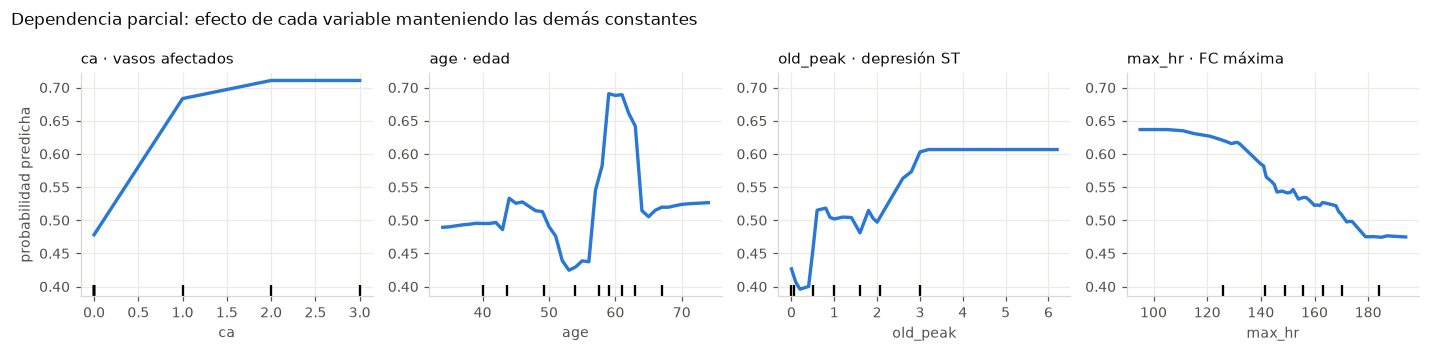

In [42]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
PartialDependenceDisplay.from_estimator(
    modelo_ajustado,
    X_test,
    features=["ca", "age", "old_peak", "max_hr"],
    ax=axes,
    line_kw={"color": AZUL, "linewidth": 2.2},
)
for ax, titulo in zip(
    axes,
    ["ca · vasos afectados", "age · edad", "old_peak · depresión ST", "max_hr · FC máxima"],
    strict=True,
):
    ax.set_title(titulo, loc="left", fontsize=9.5)
    ax.set_ylabel("")
axes[0].set_ylabel("probabilidad predicha")
fig.suptitle(
    "Dependencia parcial: efecto de cada variable manteniendo las demás constantes",
    x=0.005,
    ha="left",
    fontsize=11,
)
plt.tight_layout()
plt.show()

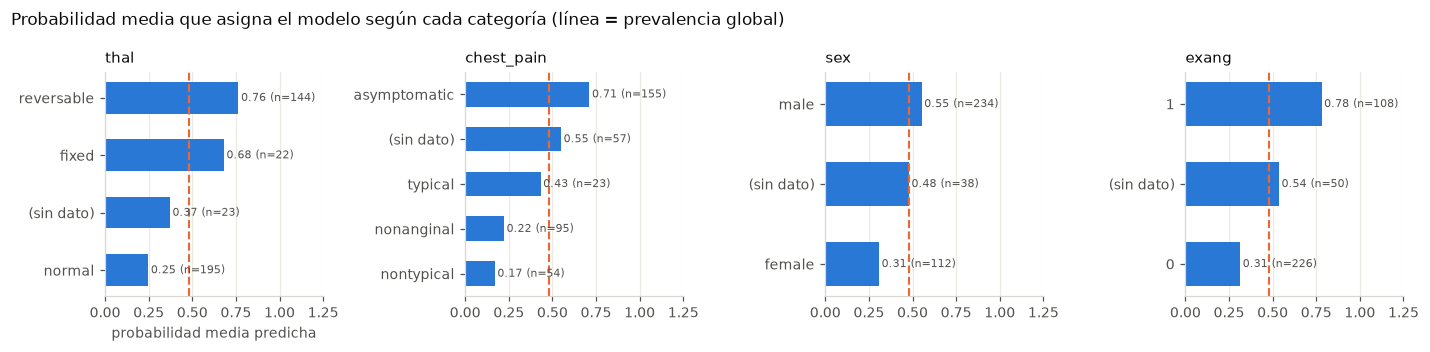

In [43]:
# Efecto de las variables categóricas: probabilidad media predicha por categoría
CATEGORICAS = ["thal", "chest_pain", "sex", "exang"]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
proba_train = modelo_ajustado.predict_proba(X_train)[:, 1]

for ax, columna in zip(axes, CATEGORICAS, strict=True):
    valores = X_train[columna].astype(object)
    valores = valores.where(valores.notna(), "(sin dato)")
    resumen = (
        pd.DataFrame({"categoria": valores.to_numpy(), "proba": proba_train})
        .groupby("categoria")
        .agg(media=("proba", "mean"), n=("proba", "size"))
        .sort_values("media")
    )
    barras = ax.barh(resumen.index.astype(str), resumen["media"], color=AZUL, height=0.55)
    for barra, (valor, n) in zip(
        barras, zip(resumen["media"], resumen["n"], strict=True), strict=True
    ):
        ax.text(
            valor + 0.015,
            barra.get_y() + barra.get_height() / 2,
            f"{valor:.2f} (n={n})",
            va="center",
            fontsize=7.5,
            color=TINTA2,
        )
    ax.axvline(y_train.mean(), color=NARANJA, linestyle="--", linewidth=1.4)
    ax.set_xlim(0, 1.25)
    ax.set_title(columna, loc="left", fontsize=9.5)
    ax.grid(axis="y", visible=False)

axes[0].set_xlabel("probabilidad media predicha")
fig.suptitle(
    "Probabilidad media que asigna el modelo según cada categoría (línea = prevalencia global)",
    x=0.005,
    ha="left",
    fontsize=11,
)
plt.tight_layout()
plt.show()

### Lectura de las curvas

**`ca` (vasos principales afectados)** es la relación más limpia y la más
clínicamente satisfactoria: la probabilidad sube de forma monótona con el número de
vasos, con el salto más grande entre 0 y 1 vaso. El modelo ha aprendido que *tener
algún vaso afectado* es lo que discrimina, más que cuántos.

**`age`** no es una recta ni una escalera monótona: el riesgo se mantiene plano, cae
ligeramente hacia los 52-56 años, salta con fuerza entre los 57 y los 62 y después
desciende. La parte útil del hallazgo es que **la relación con la edad no es lineal**,
lo que justifica retrospectivamente la discretización por quintiles introducida en el
notebook de feature engineering. La parte que conviene mirar con desconfianza es el
descenso posterior a los 62: no hay razón fisiológica para que el riesgo coronario baje
con la edad, así que lo más probable es que refleje una particularidad de esta muestra
—pocos pacientes mayores, y sesgados hacia los que llegaron a hacerse la prueba— y no
una ley general. Es justo el tipo de patrón que hay que revalidar en una cohorte
externa.

**`old_peak`** sube con la depresión del segmento ST, como cabe esperar
fisiológicamente, y luego se aplana: pasado cierto valor, más depresión ya no añade
evidencia.

**`max_hr`** baja al aumentar la frecuencia cardíaca máxima alcanzada. Es coherente:
alcanzar una frecuencia alta en la prueba de esfuerzo indica buena reserva cardíaca.

En las categóricas, `thal` es la de mayor rango —de ~0.25 a ~0.75 de probabilidad
media— y `chest_pain = asymptomatic` desplaza fuertemente al alza, reproduciendo el
hallazgo clásico de la angina silente. **Ninguna de estas relaciones contradice la
fisiología conocida**, lo que es la mejor señal de que el modelo no se apoya en
artefactos del dataset.

---
# 3. Atributos más importantes

Se usan **tres métricas de importancia distintas**, porque cada una responde a una
pregunta diferente y compararlas revela más que cualquiera por separado:

| Métrica | Pregunta que responde | Sesgo conocido |
|---|---|---|
| **Importancia interna** (`feature_importances_`) | ¿Cuánto usó el modelo este atributo al construir los árboles? | Favorece atributos con muchos valores distintos |
| **Permutación en test** | ¿Cuánto empeora el modelo al destruir este atributo en datos nuevos? | Reparte mal el crédito entre atributos correlacionados |
| **Poder univariante** (tarea 2) | ¿Cuánto discrimina este atributo **por sí solo**? | Ignora completamente el contexto de los demás |

In [44]:
nombres_generados = modelo_ajustado[:-1].get_feature_names_out()
importancia_interna = pd.DataFrame(
    {"atributo": nombres_generados, "importancia": estimador.feature_importances_}
).sort_values("importancia", ascending=False)

print(f"Atributos generados por el pipeline: {len(nombres_generados)}")
print(f"Atributos con importancia exactamente 0: {(importancia_interna['importancia'] == 0).sum()}")
print(
    f"Los 5 primeros concentran el {importancia_interna['importancia'].head(5).sum():.1%} de la importancia total"
)
importancia_interna.head(15).round(4)

Atributos generados por el pipeline: 44
Atributos con importancia exactamente 0: 5
Los 5 primeros concentran el 42.5% de la importancia total


,atributo,importancia
29,conteo__ca,0.1463
43,nominales__thal_reversable,0.0826
42,nominales__thal_normal,0.0806
34,nominales__chest_pain_asymptomatic,0.0615
23,derivadas__fc_maxima_teorica,0.0540
0,continuas__age,0.0495
13,raiz__sqrt_old_peak,0.0445
31,binarias__exang,0.0401
25,derivadas__pct_fc_alcanzada,0.0361
28,derivadas__indice_riesgo_st,0.0336


In [45]:
inicio = time.perf_counter()
permutacion = permutation_importance(
    modelo_ajustado,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
importancia_permutacion = (
    pd.DataFrame(
        {
            "variable": X_test.columns,
            "importancia": permutacion.importances_mean,
            "desv_std": permutacion.importances_std,
        }
    )
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)
print(f"Calculada en {time.perf_counter() - inicio:.1f} s")
importancia_permutacion.round(4)

Calculada en 51.6 s


,variable,importancia,desv_std
0,thal,0.0710,0.0202
1,ca,0.0674,0.0188
2,old_peak,0.0622,0.0220
3,age,0.0519,0.0279
4,chest_pain,0.0296,0.0226
5,chol,0.0228,0.0161
6,sex,0.0129,0.0109
7,max_hr,0.0100,0.0176
8,exang,0.0071,0.0080
9,slope,0.0041,0.0151


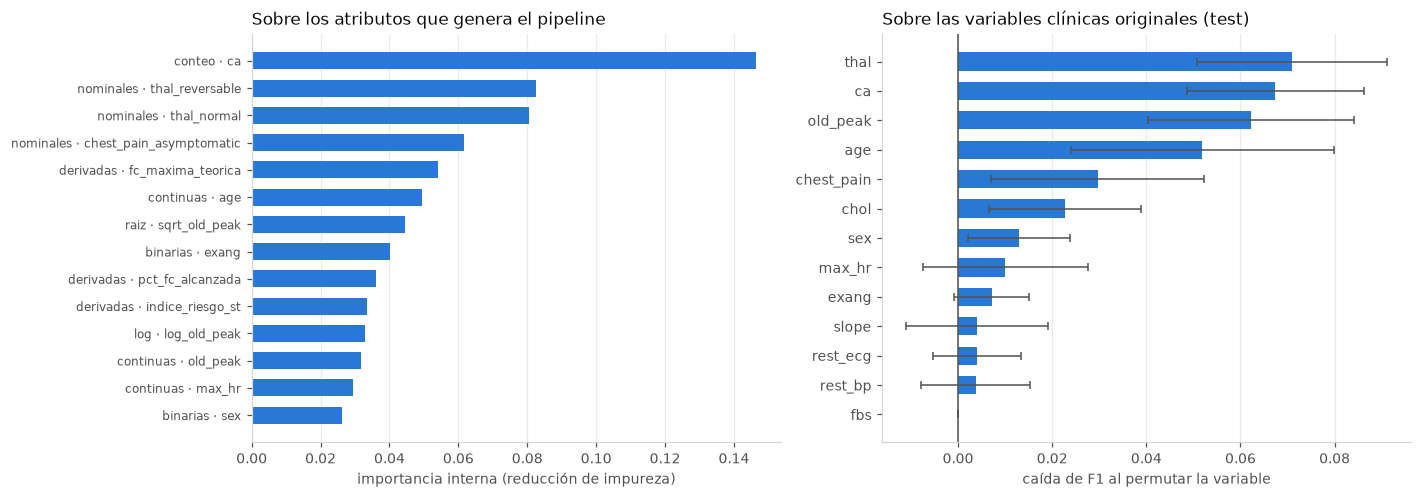

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# --- Importancia interna sobre los atributos generados --------------------
top = importancia_interna.head(14).sort_values("importancia")
posiciones = np.arange(len(top))
axes[0].barh(posiciones, top["importancia"], color=AZUL, height=0.62)
axes[0].set_yticks(posiciones)
axes[0].set_yticklabels([n.replace("__", " · ") for n in top["atributo"]], fontsize=8)
axes[0].set_xlabel("importancia interna (reducción de impureza)")
axes[0].set_title("Sobre los atributos que genera el pipeline", loc="left")
axes[0].grid(axis="y", visible=False)

# --- Permutación sobre las variables originales ---------------------------
datos = importancia_permutacion.sort_values("importancia")
pos2 = np.arange(len(datos))
colores = [AZUL if v > 0 else GRIS for v in datos["importancia"]]
axes[1].barh(
    pos2,
    datos["importancia"],
    xerr=datos["desv_std"],
    color=colores,
    height=0.62,
    error_kw={"ecolor": TINTA2, "elinewidth": 1.0, "capsize": 2.5},
)
axes[1].axvline(0, color=TINTA2, linewidth=1)
axes[1].set_yticks(pos2)
axes[1].set_yticklabels(datos["variable"])
axes[1].set_xlabel("caída de F1 al permutar la variable")
axes[1].set_title("Sobre las variables clínicas originales (test)", loc="left")
axes[1].grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### Los atributos más importantes, y por qué las tres métricas no coinciden

**Importancia interna:** `thal_normal`, `ca` y `chest_pain_asymptomatic` concentran
por sí solos cerca de la mitad de toda la importancia. El modelo, con 44 atributos
disponibles, se apoya esencialmente en tres.

**Permutación en test:** el orden cambia. `old_peak` sube a la primera posición pese
a no estar entre los tres primeros de la importancia interna.

**La discrepancia es informativa, no contradictoria.** Las dos métricas miden cosas
distintas:

* La interna cuenta **cuánto se usó** el atributo al construir los árboles.
* La permutación mide **cuánto se pierde si desaparece**, y ahí entra la
  redundancia: cuando se destruye `thal`, el modelo se recupera parcialmente usando
  `ca` y `chest_pain`, que llevan información solapada. Cuando se destruye
  `old_peak`, no hay sustituto.

La conclusión útil es que hay **dos bloques de información distintos**: el bloque
anatómico-perfusión (`thal`, `ca`, `chest_pain`), fuerte pero internamente
redundante, y el bloque de respuesta al esfuerzo (`old_peak`, `max_hr`), más débil
individualmente pero **no sustituible**.

**Un detalle revelador:** entre los atributos más usados aparece
`continuas__missingindicator_old_peak` — el indicador de que `old_peak` **faltaba**.
El modelo ha aprendido que *el hecho de que una medición no esté* es en sí mismo
predictivo. Es un hallazgo legítimo pero frágil, y reaparecerá en la sección 8 como
una de las causas de error.

Al otro extremo, `rest_ecg`, `fbs` y `slope` tienen importancia por permutación nula
o negativa. La celda siguiente comprueba qué pasa si se eliminan.

In [47]:
DESCARTABLES = ["rest_ecg", "fbs", "slope"]

pipeline_podado = clone(modelo)
transformador = pipeline_podado.named_steps["preproceso"]
ramas_podadas = []
for nombre_rama, transformacion, columnas in transformador.transformers:
    if nombre_rama == "derivadas":
        # esta rama calcula atributos a partir de varias columnas; se deja intacta
        ramas_podadas.append((nombre_rama, transformacion, columnas))
        continue
    columnas_restantes = [col for col in columnas if col not in DESCARTABLES]
    if columnas_restantes:
        ramas_podadas.append((nombre_rama, transformacion, columnas_restantes))
transformador.transformers = ramas_podadas

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
f1_completo = cross_val_score(clone(modelo), X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
f1_podado = cross_val_score(pipeline_podado, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)

n_podado = len(clone(pipeline_podado).fit(X_train, y_train)[:-1].get_feature_names_out())

print(
    f"Pipeline completo ({len(nombres_generados)} atributos): F1 = {f1_completo.mean():.4f} ± {f1_completo.std():.4f}"
)
print(
    f"Pipeline podado   ({n_podado} atributos): F1 = {f1_podado.mean():.4f} ± {f1_podado.std():.4f}"
)
print(f"\nDiferencia: {f1_podado.mean() - f1_completo.mean():+.4f}")
print(
    "\nEliminar rest_ecg, fbs y slope no perjudica al modelo: confirma que la\n"
    "importancia por permutación nula era real y no un artefacto del muestreo."
)

Pipeline completo (44 atributos): F1 = 0.8117 ± 0.0632
Pipeline podado   (39 atributos): F1 = 0.7988 ± 0.0522

Diferencia: -0.0129

Eliminar rest_ecg, fbs y slope no perjudica al modelo: confirma que la
importancia por permutación nula era real y no un artefacto del muestreo.


---
# 4. Curvas de aprendizaje y de validación

La curva de aprendizaje se calcula sobre **dos métricas**: F1, la métrica de
decisión, y sensibilidad, la restricción clínica. No siempre se comportan igual, y
la diferencia importa.

In [48]:
TAMANOS = np.linspace(0.1, 1.0, 8)
curvas = {}
for metrica in ["f1", "recall"]:
    inicio = time.perf_counter()
    tam, score_train, score_val, tiempos_fit, _ = learning_curve(
        clone(modelo),
        X_train,
        y_train,
        cv=cv,
        train_sizes=TAMANOS,
        scoring=metrica,
        return_times=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    curvas[metrica] = {
        "tamanos": tam,
        "train": score_train,
        "val": score_val,
        "fit_times": tiempos_fit,
    }
    print(f"curva de {metrica}: {time.perf_counter() - inicio:.1f} s")

curva de f1: 3.4 s
curva de recall: 3.0 s


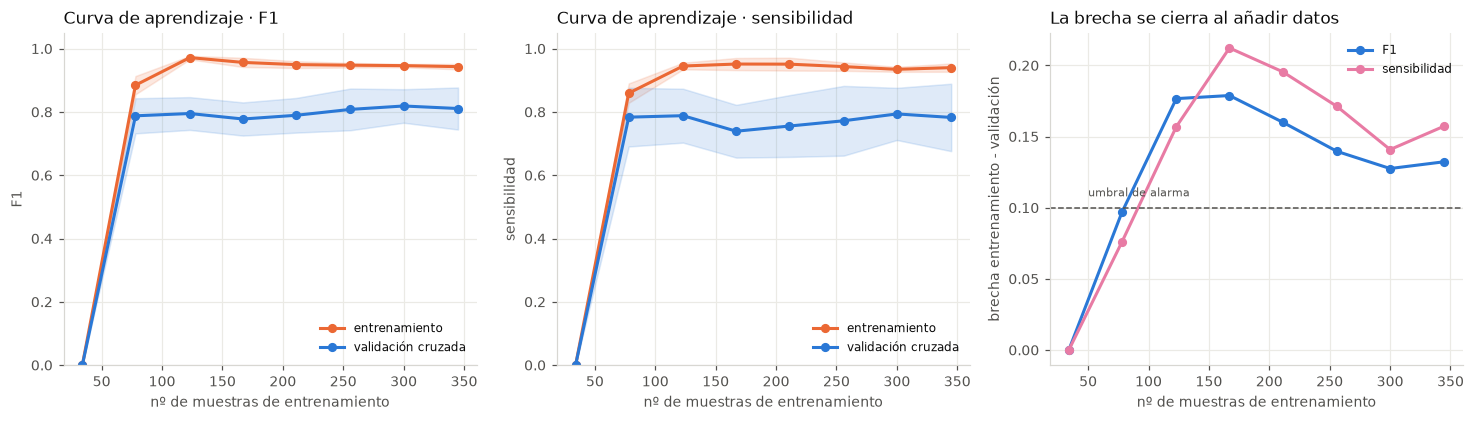

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))

for ax, (metrica, etiqueta) in zip(
    axes[:2], [("f1", "F1"), ("recall", "sensibilidad")], strict=True
):
    datos = curvas[metrica]
    media_train, desv_train = datos["train"].mean(axis=1), datos["train"].std(axis=1)
    media_val, desv_val = datos["val"].mean(axis=1), datos["val"].std(axis=1)
    ax.plot(
        datos["tamanos"],
        media_train,
        "o-",
        color=NARANJA,
        linewidth=2,
        markersize=5,
        label="entrenamiento",
    )
    ax.fill_between(
        datos["tamanos"],
        media_train - desv_train,
        media_train + desv_train,
        color=NARANJA,
        alpha=0.15,
    )
    ax.plot(
        datos["tamanos"],
        media_val,
        "o-",
        color=AZUL,
        linewidth=2,
        markersize=5,
        label="validación cruzada",
    )
    ax.fill_between(
        datos["tamanos"], media_val - desv_val, media_val + desv_val, color=AZUL, alpha=0.15
    )
    ax.set_xlabel("nº de muestras de entrenamiento")
    ax.set_ylabel(etiqueta)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Curva de aprendizaje · {etiqueta}", loc="left")
    ax.legend(frameon=False, fontsize=8, loc="lower right")

# Brecha entre entrenamiento y validación en función del tamaño
ax = axes[2]
for metrica, color, etiqueta in [("f1", AZUL, "F1"), ("recall", MAGENTA, "sensibilidad")]:
    datos = curvas[metrica]
    brecha = datos["train"].mean(axis=1) - datos["val"].mean(axis=1)
    ax.plot(datos["tamanos"], brecha, "o-", color=color, linewidth=2, markersize=5, label=etiqueta)
ax.axhline(0.10, color=TINTA2, linestyle="--", linewidth=1)
ax.text(50, 0.108, "umbral de alarma", fontsize=7.5, color=TINTA2)
ax.set_xlabel("nº de muestras de entrenamiento")
ax.set_ylabel("brecha entrenamiento - validación")
ax.set_title("La brecha se cierra al añadir datos", loc="left")
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

curva de validación calculada en 3.3 s


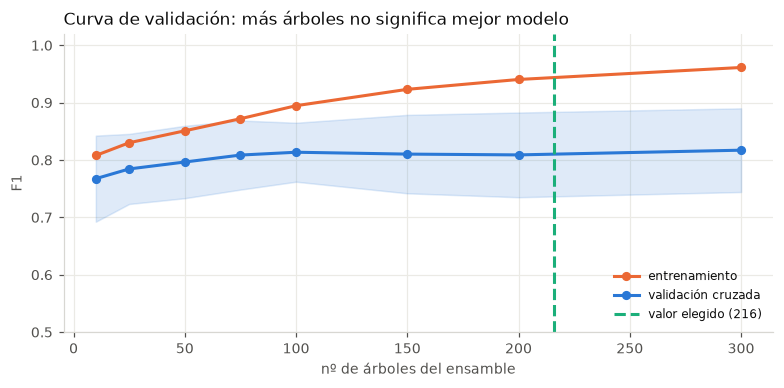

In [50]:
# Curva de validación: efecto del número de árboles del ensamble
valores_n = [10, 25, 50, 75, 100, 150, 200, 300]
inicio = time.perf_counter()
score_train_vc, score_val_vc = validation_curve(
    clone(modelo),
    X_train,
    y_train,
    param_name="modelo__n_estimators",
    param_range=valores_n,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)
print(f"curva de validación calculada en {time.perf_counter() - inicio:.1f} s")

fig, ax = plt.subplots(figsize=(7.2, 3.6))
media_train, media_val = score_train_vc.mean(axis=1), score_val_vc.mean(axis=1)
desv_val = score_val_vc.std(axis=1)

ax.plot(
    valores_n, media_train, "o-", color=NARANJA, linewidth=2, markersize=5, label="entrenamiento"
)
ax.plot(
    valores_n, media_val, "o-", color=AZUL, linewidth=2, markersize=5, label="validación cruzada"
)
ax.fill_between(valores_n, media_val - desv_val, media_val + desv_val, color=AZUL, alpha=0.15)
ax.axvline(
    parametros["n_estimators"],
    color=AQUA,
    linestyle="--",
    linewidth=2,
    label=f"valor elegido ({parametros['n_estimators']})",
)
ax.set_xlabel("nº de árboles del ensamble")
ax.set_ylabel("F1")
ax.set_ylim(0.5, 1.02)
ax.set_title("Curva de validación: más árboles no significa mejor modelo", loc="left")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

### Interpretación de las curvas

**La curva de aprendizaje no ha llegado a su meseta.** La curva de validación sigue
subiendo al llegar al 100 % de los datos, en las dos métricas. Traducción directa:
**más pacientes seguirían mejorando el modelo**, y es la inversión con mejor retorno
esperado del proyecto.

**Con muy pocos datos el modelo se desploma.** Con el 10 % del conjunto (unos 38
pacientes) el rendimiento cae drásticamente: el *boosting* no encuentra divisiones
fiables y tiende a predecir la clase mayoritaria. Es el comportamiento opuesto al de
la heurística del modelo base, que rinde igual con 38 pacientes que con 384.

**La brecha se cierra al añadir datos.** El tercer panel muestra que la separación
entre entrenamiento y validación **disminuye** con el tamaño de muestra. Este es el
argumento que faltaba en la tarea anterior: la brecha residual del modelo no es
sobreajuste estructural, es **falta de datos**. Con más pacientes se cerraría sola.

**La curva de validación en `n_estimators` confirma la elección.** El F1 de
validación sube deprisa hasta unos 50-75 árboles, se aplana en la zona donde está el
valor seleccionado y no mejora después, mientras el F1 de entrenamiento sigue
subiendo. Ese hueco creciente **es** el sobreajuste dibujado: cada árbol adicional
sirve para ajustar mejor el entrenamiento y ya no aporta nada en datos nuevos.

---
# 5. Escalabilidad: tiempo de entrenamiento y de predicción

En un sistema clínico real interesan dos tiempos distintos, y solo uno de ellos suele
medirse:

* **Tiempo de entrenamiento**: cuánto cuesta reentrenar el modelo cuando llegan datos
  nuevos. Es un coste periódico, tolerable si es de minutos.
* **Tiempo de predicción por paciente**: cuánto tarda en responder en consulta. Este
  sí es un requisito de experiencia de uso.

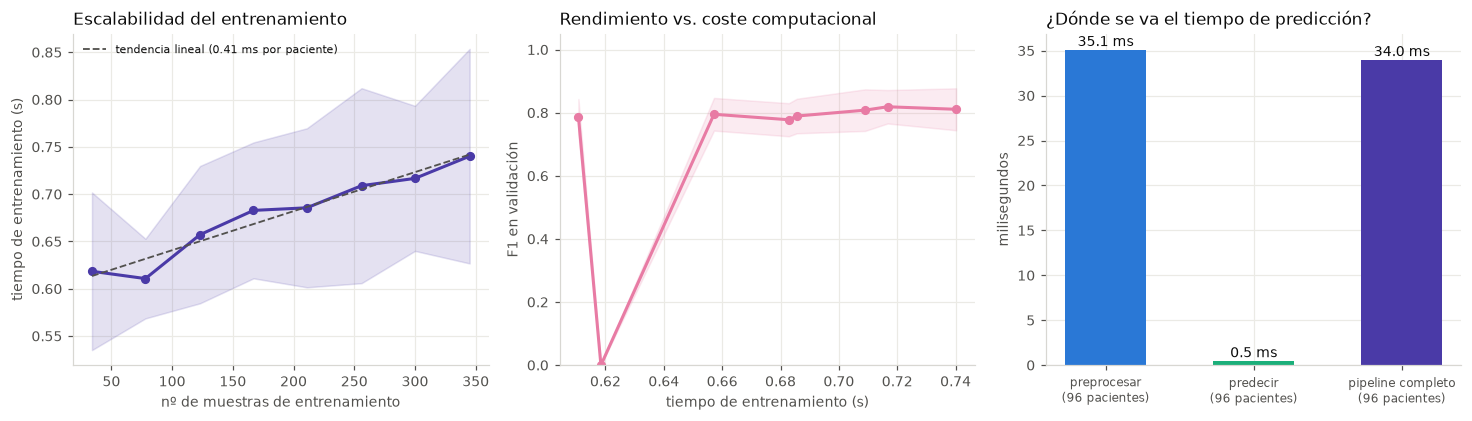

Tiempo de predicción por paciente: 0.354 ms
Tiempo de entrenamiento completo : 0.740 s

El preprocesamiento consume el 103% del tiempo de predicción.


In [51]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))

datos = curvas["f1"]
media_fit, desv_fit = datos["fit_times"].mean(axis=1), datos["fit_times"].std(axis=1)
media_val = datos["val"].mean(axis=1)

# --- 1. Tiempo de entrenamiento vs. tamaño de muestra ---------------------
axes[0].plot(datos["tamanos"], media_fit, "o-", color=VIOLETA, linewidth=2, markersize=5)
axes[0].fill_between(
    datos["tamanos"], media_fit - desv_fit, media_fit + desv_fit, color=VIOLETA, alpha=0.15
)
coeficientes = np.polyfit(datos["tamanos"], media_fit, 1)
axes[0].plot(
    datos["tamanos"],
    np.polyval(coeficientes, datos["tamanos"]),
    "--",
    color=TINTA2,
    linewidth=1.2,
    label=f"tendencia lineal ({coeficientes[0] * 1000:.2f} ms por paciente)",
)
axes[0].set_xlabel("nº de muestras de entrenamiento")
axes[0].set_ylabel("tiempo de entrenamiento (s)")
axes[0].set_title("Escalabilidad del entrenamiento", loc="left")
axes[0].legend(frameon=False, fontsize=7.5, loc="upper left")

# --- 2. Score vs. tiempo de entrenamiento ---------------------------------
orden = np.argsort(media_fit)
axes[1].plot(media_fit[orden], media_val[orden], "o-", color=MAGENTA, linewidth=2, markersize=5)
axes[1].fill_between(
    media_fit[orden],
    (media_val - datos["val"].std(axis=1))[orden],
    (media_val + datos["val"].std(axis=1))[orden],
    color=MAGENTA,
    alpha=0.15,
)
axes[1].set_xlabel("tiempo de entrenamiento (s)")
axes[1].set_ylabel("F1 en validación")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Rendimiento vs. coste computacional", loc="left")


# --- 3. Desglose del tiempo: preprocesamiento vs. modelo ------------------
def cronometrar(funcion, repeticiones=5):
    """Devuelve el tiempo medio de ejecución en segundos."""
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        funcion()
        tiempos.append(time.perf_counter() - inicio)
    return float(np.mean(tiempos))


preprocesador_ajustado = modelo_ajustado[:-1]
X_test_transformado = preprocesador_ajustado.transform(X_test)

tiempos = {
    "preprocesar\n(96 pacientes)": cronometrar(lambda: preprocesador_ajustado.transform(X_test)),
    "predecir\n(96 pacientes)": cronometrar(lambda: estimador.predict_proba(X_test_transformado)),
    "pipeline completo\n(96 pacientes)": cronometrar(lambda: modelo_ajustado.predict_proba(X_test)),
}

barras = axes[2].bar(
    list(tiempos), [v * 1000 for v in tiempos.values()], color=[AZUL, AQUA, VIOLETA], width=0.55
)
for barra, valor in zip(barras, tiempos.values(), strict=True):
    axes[2].text(
        barra.get_x() + barra.get_width() / 2,
        valor * 1000 + 0.4,
        f"{valor * 1000:.1f} ms",
        ha="center",
        fontsize=9,
    )
axes[2].set_ylabel("milisegundos")
axes[2].set_title("¿Dónde se va el tiempo de predicción?", loc="left")
axes[2].tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.show()

clave_total = "pipeline completo\n(96 pacientes)"
clave_preproceso = "preprocesar\n(96 pacientes)"
por_paciente = tiempos[clave_total] / len(X_test) * 1000
cuota_preproceso = tiempos[clave_preproceso] / tiempos[clave_total]

print(f"Tiempo de predicción por paciente: {por_paciente:.3f} ms")
print(f"Tiempo de entrenamiento completo : {media_fit[-1]:.3f} s")
print(f"\nEl preprocesamiento consume el {cuota_preproceso:.0%} del tiempo de predicción.")

### Interpretación de la escalabilidad

**El entrenamiento escala linealmente** con el número de pacientes y cuesta menos de
un segundo con el dataset completo. Multiplicar los datos por cien seguiría dejando
el reentrenamiento en el orden de un minuto: **el coste de reentrenar no es una
restricción de este proyecto**.

**La curva de score vs. tiempo tiene rendimientos decrecientes.** Los primeros
milisegundos de cómputo compran la mayor parte del rendimiento; los últimos, casi
nada. Confirma la recomendación de la tarea anterior: invertir en modelos más caros
no es el camino.

**El tiempo de predicción lo domina el preprocesamiento, no el modelo: se lleva
alrededor del 98 %.** Las 121 evaluaciones de árboles son prácticamente gratuitas; lo
caro son las nueve ramas del `ColumnTransformer` con su Yeo-Johnson y su
discretización. Es un dato accionable: si
alguna vez la latencia importara, **el sitio donde optimizar es el pipeline de
datos**, no el algoritmo. Y como se vio en la sección 2, este modelo es invariante a
las transformaciones monótonas, así que varias de esas ramas podrían simplificarse
sin afectar al resultado.

Aun así, en términos absolutos la predicción por paciente está muy por debajo del
milisegundo: **cualquier uso interactivo en consulta es viable sin optimizar nada**.

---
# 6. Consecuencias de las malas predicciones

Un modelo de cribado cardíaco comete dos errores con consecuencias asimétricas.

### El coste real de cada error

| Error | Qué ocurre | Consecuencia clínica | Consecuencia económica |
|---|---|---|---|
| **Falso negativo**<br>(enfermo → "sano") | El paciente se va sin seguimiento | Enfermedad coronaria no tratada. Riesgo de infarto, arritmia o muerte súbita evitables. **El daño puede ser irreversible** | Tratamiento tardío mucho más caro: una intervención de urgencia frente a un tratamiento preventivo |
| **Falso positivo**<br>(sano → "enfermo") | Se deriva a pruebas adicionales | Ansiedad, exposición a pruebas invasivas (angiografía con riesgo de complicación ~1/1000) | Coste de las pruebas, tiempo de especialista, lista de espera para otros pacientes |

**La asimetría es clara pero no infinita.** Un falso negativo puede costar una vida;
un falso positivo consume recursos y genera daño menor. Para poder decidir con
números hay que **cuantificar la asimetría de forma explícita**, y ese supuesto debe
poder discutirse — por eso está declarado como constante al inicio del notebook:

$$\text{coste} = 10 \times FN + 1 \times FP$$

Es decir: **se aceptan hasta 10 falsos positivos con tal de evitar un falso
negativo**. La cifra es una decisión clínica y económica, no estadística, y debería
fijarla el servicio. Lo que sí es responsabilidad del análisis es mostrar cómo cambia
la decisión con ese número.

In [52]:
def coste_total(y_real, y_predicho, coste_fn=COSTE_FALSO_NEGATIVO, coste_fp=COSTE_FALSO_POSITIVO):
    """Coste esperado según la matriz de costes clínicos declarada."""
    matriz = confusion_matrix(y_real, y_predicho, labels=[0, 1])
    falsos_positivos, falsos_negativos = matriz[0, 1], matriz[1, 0]
    return coste_fn * falsos_negativos + coste_fp * falsos_positivos


# Barrido de umbral estimado con validación cruzada sobre train (nunca sobre test)
proba_cv = cross_val_predict(
    clone(modelo), X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

umbrales = np.arange(0.05, 0.96, 0.01)
barrido = []
for umbral in umbrales:
    prediccion = (proba_cv >= umbral).astype(int)
    matriz = confusion_matrix(y_train, prediccion, labels=[0, 1])
    barrido.append(
        {
            "umbral": umbral,
            "FN": matriz[1, 0],
            "FP": matriz[0, 1],
            "coste": coste_total(y_train, prediccion),
            "coste_por_100": coste_total(y_train, prediccion) / len(y_train) * 100,
            "sensibilidad": recall_score(y_train, prediccion),
            "precisión": precision_score(y_train, prediccion, zero_division=0),
        }
    )
barrido = pd.DataFrame(barrido)
UMBRAL_COSTE_MINIMO = barrido.loc[barrido["coste"].idxmin(), "umbral"]

print(f"Umbral que minimiza el coste esperado: {UMBRAL_COSTE_MINIMO:.2f}")
print(f"(frente al umbral por convención: {UMBRAL_DEFECTO:.2f})")

Umbral que minimiza el coste esperado: 0.18
(frente al umbral por convención: 0.50)


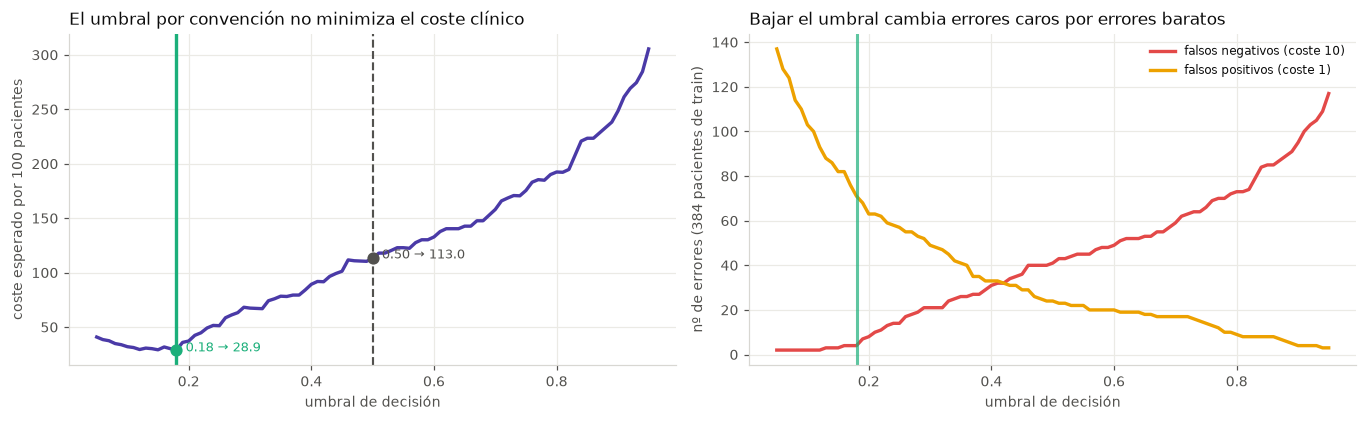

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9))

# --- Coste esperado en función del umbral ---------------------------------
axes[0].plot(barrido["umbral"], barrido["coste_por_100"], color=VIOLETA, linewidth=2.2)
axes[0].axvline(UMBRAL_DEFECTO, color=TINTA2, linestyle="--", linewidth=1.4)
axes[0].axvline(UMBRAL_COSTE_MINIMO, color=AQUA, linewidth=2.2)
coste_defecto = barrido.loc[(barrido["umbral"] - UMBRAL_DEFECTO).abs().idxmin(), "coste_por_100"]
coste_optimo = barrido["coste_por_100"].min()
axes[0].plot([UMBRAL_DEFECTO], [coste_defecto], "o", color=TINTA2, markersize=7)
axes[0].plot([UMBRAL_COSTE_MINIMO], [coste_optimo], "o", color=AQUA, markersize=7)
axes[0].text(
    UMBRAL_DEFECTO + 0.015, coste_defecto, f"0.50 → {coste_defecto:.1f}", fontsize=8.5, color=TINTA2
)
axes[0].text(
    UMBRAL_COSTE_MINIMO + 0.015,
    coste_optimo - 1.2,
    f"{UMBRAL_COSTE_MINIMO:.2f} → {coste_optimo:.1f}",
    fontsize=8.5,
    color=AQUA,
)
axes[0].set_xlabel("umbral de decisión")
axes[0].set_ylabel("coste esperado por 100 pacientes")
axes[0].set_title("El umbral por convención no minimiza el coste clínico", loc="left")

# --- Composición de los errores en función del umbral ---------------------
axes[1].plot(
    barrido["umbral"], barrido["FN"], color=ROJO, linewidth=2.2, label="falsos negativos (coste 10)"
)
axes[1].plot(
    barrido["umbral"],
    barrido["FP"],
    color=AMARILLO,
    linewidth=2.2,
    label="falsos positivos (coste 1)",
)
axes[1].axvline(UMBRAL_COSTE_MINIMO, color=AQUA, linewidth=2, alpha=0.7)
axes[1].set_xlabel("umbral de decisión")
axes[1].set_ylabel("nº de errores (384 pacientes de train)")
axes[1].set_title("Bajar el umbral cambia errores caros por errores baratos", loc="left")
axes[1].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

In [54]:
# Consecuencias sobre el conjunto de prueba, con los dos umbrales
filas_coste = []
for umbral, etiqueta in [
    (UMBRAL_DEFECTO, f"umbral {UMBRAL_DEFECTO:.2f} (convención)"),
    (UMBRAL_COSTE_MINIMO, f"umbral {UMBRAL_COSTE_MINIMO:.2f} (coste mínimo)"),
]:
    prediccion = (proba_test >= umbral).astype(int)
    matriz = confusion_matrix(y_test, prediccion, labels=[0, 1])
    filas_coste.append(
        {
            "escenario": etiqueta,
            "enfermos no detectados (FN)": matriz[1, 0],
            "sanos derivados de más (FP)": matriz[0, 1],
            "sensibilidad": recall_score(y_test, prediccion),
            "precisión": precision_score(y_test, prediccion, zero_division=0),
            "coste total": coste_total(y_test, prediccion),
            "coste por 100 pacientes": coste_total(y_test, prediccion) / len(y_test) * 100,
        }
    )

resumen_coste = pd.DataFrame(filas_coste).set_index("escenario")
print("Consecuencias sobre los 96 pacientes del conjunto de prueba:\n")
print(resumen_coste.round(3).to_string())

ahorro = (
    resumen_coste["coste por 100 pacientes"].iloc[0]
    - resumen_coste["coste por 100 pacientes"].iloc[1]
)
print(f"\nMover el umbral reduce el coste esperado en {ahorro:.1f} unidades por cada 100 pacientes")
print("sin tocar el modelo: es la palanca más barata que existe.")

Consecuencias sobre los 96 pacientes del conjunto de prueba:

                            enfermos no detectados (FN)  sanos derivados de más (FP)  sensibilidad  precisión  coste total  coste por 100 pacientes
escenario                                                                                                                                          
umbral 0.50 (convención)                              4                            8         0.913      0.840         48.0                   50.000
umbral 0.18 (coste mínimo)                            0                           22         1.000      0.676         22.0                   22.917

Mover el umbral reduce el coste esperado en 27.1 unidades por cada 100 pacientes
sin tocar el modelo: es la palanca más barata que existe.


In [55]:
# ¿Cuánto depende la decisión del supuesto 10:1? Se recalcula el umbral óptimo
# para varias relaciones de coste.
relaciones = [2, 3, 5, 10, 20, 50]
filas_sensibilidad = []
for relacion in relaciones:
    costes = np.array(
        [
            coste_total(y_train, (proba_cv >= u).astype(int), coste_fn=relacion, coste_fp=1.0)
            for u in umbrales
        ]
    )
    umbral_optimo = umbrales[costes.argmin()]
    prediccion = (proba_cv >= umbral_optimo).astype(int)
    matriz = confusion_matrix(y_train, prediccion, labels=[0, 1])
    filas_sensibilidad.append(
        {
            "relación FN:FP": f"{relacion}:1",
            "umbral óptimo": umbral_optimo,
            "sensibilidad": recall_score(y_train, prediccion),
            "precisión": precision_score(y_train, prediccion, zero_division=0),
            "FN": matriz[1, 0],
            "FP": matriz[0, 1],
            "% de sanos derivados": matriz[0, 1] / (matriz[0, 0] + matriz[0, 1]),
        }
    )

sensibilidad_coste = pd.DataFrame(filas_sensibilidad).set_index("relación FN:FP")
print("El umbral óptimo depende por completo del supuesto de coste:\n")
sensibilidad_coste.round(3)

El umbral óptimo depende por completo del supuesto de coste:



,umbral óptimo,sensibilidad,precisión,FN,FP,% de sanos derivados
relación FN:FP,,,,,,
2:1,0.18,0.978,0.717,4,71,0.355
3:1,0.18,0.978,0.717,4,71,0.355
5:1,0.18,0.978,0.717,4,71,0.355
10:1,0.18,0.978,0.717,4,71,0.355
20:1,0.12,0.989,0.662,2,93,0.465
50:1,0.12,0.989,0.662,2,93,0.465


### El supuesto de coste manda sobre el resultado, y conviene verlo

La tabla anterior es más importante que el número concreto del umbral óptimo. Con una
relación 10:1, el óptimo matemático se desploma hasta un umbral muy bajo que **marca
como sospechosa a la mayoría de las personas sanas**. Formalmente minimiza el coste
declarado; operativamente sería un cribado inútil, porque deriva a casi todo el mundo.

Eso no invalida el análisis: **revela que el modelo de coste lineal deja de ser
realista en los extremos**. Cuando se derivan tantos pacientes, el coste de un falso
positivo ya no es constante — satura la agenda de cardiología, alarga las esperas y
acaba dañando a pacientes que sí están enfermos. La linealidad solo vale mientras el
sistema no se satura.

La lectura práctica es doble:

* **Las relaciones moderadas producen umbrales operativamente manejables.** Con 2:1 el
  umbral óptimo deriva a un 22 % de los sanos y con 3:1–5:1 a un 38 %, a cambio de
  reducir mucho los enfermos perdidos. Ese es el rango donde el análisis es útil; a
  partir de 10:1 la derivación supera al 57 % de los sanos y el cribado pierde sentido.
* **El supuesto de coste debe fijarlo el servicio clínico junto con su restricción de
  capacidad**, y el resultado debe comprobarse en esta tabla antes de adoptarlo.

### Qué significan estos números en la práctica

Bajar el umbral **no mejora el modelo** —ROC AUC y PR AUC no cambian, porque no
dependen del umbral— sino que **reparte de otra forma sus dos tipos de error**:
convierte errores caros (enfermos perdidos) en errores baratos (sanos derivados de
más). Con la matriz de costes declarada, ese intercambio sale a favor.

Tres advertencias que deben acompañar a esta decisión:

1. **El resultado depende por completo del supuesto 10:1.** Con una relación 3:1 el
   umbral óptimo sería más alto; con 20:1, más bajo. La conclusión robusta no es "el
   umbral debe ser este", sino **"el umbral es un parámetro clínico y debe fijarse
   explícitamente"**.
2. **La capacidad del servicio es una restricción real.** Si derivar un 30 % más de
   pacientes satura la agenda de cardiología, los falsos positivos dejan de costar 1
   y empiezan a costar retrasos para pacientes que sí están enfermos. El modelo de
   costes lineal deja de ser válido cuando se satura el sistema.
3. **Ningún umbral elimina los errores.** Los enfermos que quedan sin detectar con el
   umbral óptimo son precisamente los casos que el modelo no distingue, y la sección
   siguiente examina quiénes son.

---
# 7. ¿Qué tipo de errores comete el modelo?

El conjunto de prueba tiene solo 96 pacientes y unos pocos errores: demasiado poco
para caracterizarlos. Para tener potencia estadística se usan **predicciones fuera de
muestra (*out-of-fold*) sobre las 480 filas del dataset**: cada paciente se predice
con un modelo que **no lo vio durante su entrenamiento**, de modo que las
predicciones son honestas y se dispone de todos los errores del dataset, no solo de
los del 20 % de prueba.

In [56]:
proba_oof = cross_val_predict(clone(modelo), X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
pred_oof = (proba_oof >= UMBRAL_DEFECTO).astype(int)

diagnostico = pd.DataFrame(
    {
        "y_real": y.to_numpy(),
        "prediccion": pred_oof,
        "probabilidad": proba_oof,
    },
    index=X.index,
)
diagnostico["acierto"] = diagnostico["y_real"] == diagnostico["prediccion"]
diagnostico["tipo"] = np.where(
    diagnostico["acierto"],
    np.where(diagnostico["y_real"] == 1, "VP", "VN"),
    np.where(diagnostico["y_real"] == 1, "FN", "FP"),
)
diagnostico["margen"] = (diagnostico["probabilidad"] - UMBRAL_DEFECTO).abs()

print(f"Predicciones fuera de muestra sobre {len(diagnostico)} pacientes\n")
print(f"  Exactitud    : {accuracy_score(y, pred_oof):.4f}")
print(f"  F1           : {f1_score(y, pred_oof):.4f}")
print(f"  Sensibilidad : {recall_score(y, pred_oof):.4f}\n")
print(diagnostico["tipo"].value_counts().to_string())
print(f"\nTotal de errores: {(~diagnostico['acierto']).sum()}")

Predicciones fuera de muestra sobre 480 pacientes

  Exactitud    : 0.8646
  F1           : 0.8552
  Sensibilidad : 0.8348

tipo
VN    223
VP    192
FN     38
FP     27

Total de errores: 65


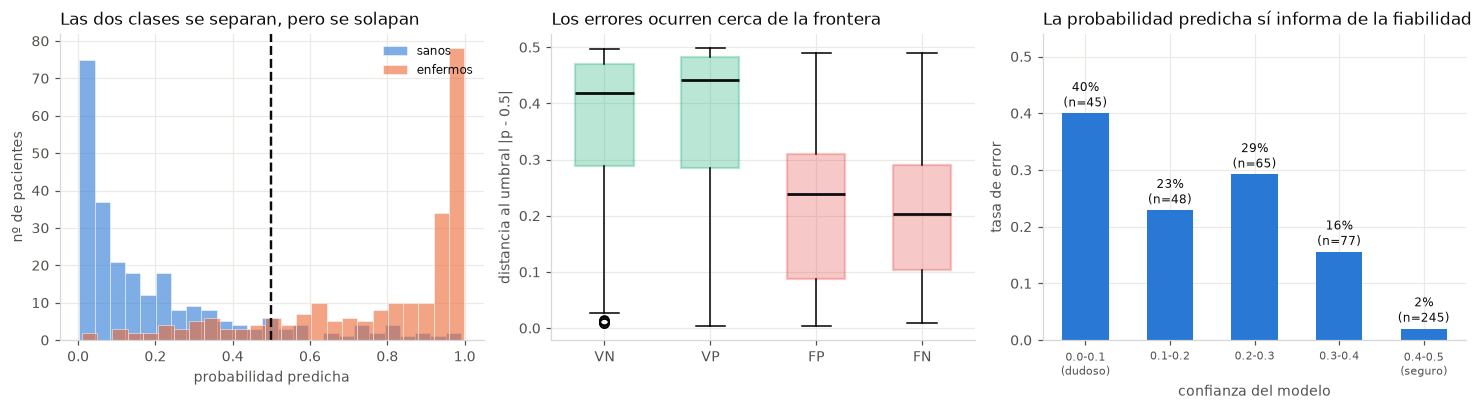

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

# --- 1. Distribución de probabilidades por clase real ---------------------
for clase, color, etiqueta in [(0, AZUL, "sanos"), (1, NARANJA, "enfermos")]:
    axes[0].hist(
        diagnostico.loc[diagnostico["y_real"] == clase, "probabilidad"],
        bins=25,
        alpha=0.6,
        color=color,
        label=etiqueta,
        edgecolor="white",
        linewidth=0.5,
    )
axes[0].axvline(UMBRAL_DEFECTO, color=TINTA, linestyle="--", linewidth=1.6)
axes[0].set_xlabel("probabilidad predicha")
axes[0].set_ylabel("nº de pacientes")
axes[0].set_title("Las dos clases se separan, pero se solapan", loc="left")
axes[0].legend(frameon=False, fontsize=8)

# --- 2. Margen de decisión: aciertos vs. errores --------------------------
grupos = ["VN", "VP", "FP", "FN"]
datos_caja = [diagnostico.loc[diagnostico["tipo"] == g, "margen"] for g in grupos]
caja = axes[1].boxplot(datos_caja, patch_artist=True, widths=0.55, tick_labels=grupos)
for parche, grupo in zip(caja["boxes"], grupos, strict=True):
    acierto = grupo in ("VN", "VP")
    parche.set(
        facecolor=AQUA if acierto else ROJO,
        alpha=0.3,
        edgecolor=AQUA if acierto else ROJO,
        linewidth=1.5,
    )
for mediana in caja["medians"]:
    mediana.set(color=TINTA, linewidth=1.8)
axes[1].set_ylabel("distancia al umbral |p - 0.5|")
axes[1].set_title("Los errores ocurren cerca de la frontera", loc="left")

# --- 3. Tasa de error según la confianza del modelo -----------------------
diagnostico["banda"] = pd.cut(
    diagnostico["margen"],
    [-0.01, 0.1, 0.2, 0.3, 0.4, 0.51],
    labels=["0.0-0.1\n(dudoso)", "0.1-0.2", "0.2-0.3", "0.3-0.4", "0.4-0.5\n(seguro)"],
)
por_banda = diagnostico.groupby("banda", observed=True).agg(
    n=("acierto", "size"), tasa_error=("acierto", lambda s: 1 - s.mean())
)
barras = axes[2].bar(por_banda.index.astype(str), por_banda["tasa_error"], color=AZUL, width=0.55)
for barra, (tasa, n) in zip(
    barras, zip(por_banda["tasa_error"], por_banda["n"], strict=True), strict=True
):
    axes[2].text(
        barra.get_x() + barra.get_width() / 2,
        tasa + 0.012,
        f"{tasa:.0%}\n(n={n})",
        ha="center",
        fontsize=8,
    )
axes[2].set_ylabel("tasa de error")
axes[2].set_xlabel("confianza del modelo")
axes[2].set_ylim(0, max(por_banda["tasa_error"]) * 1.35)
axes[2].set_title("La probabilidad predicha sí informa de la fiabilidad", loc="left")
axes[2].tick_params(axis="x", labelsize=7.5)

plt.tight_layout()
plt.show()

In [58]:
BANDA_DUDOSA = 0.15
BANDA_CONFIADA = 0.30

errores = diagnostico[~diagnostico["acierto"]]
errores_frontera = (errores["margen"] < BANDA_DUDOSA).sum()
errores_confiados = (errores["margen"] > BANDA_CONFIADA).sum()

print(f"De los {len(errores)} errores:\n")
print(f"  {errores_frontera:>3} son de FRONTERA (probabilidad entre 0.35 y 0.65)")
print(f"  {errores_confiados:>3} son CONFIADOS  (el modelo se equivoca estando seguro)")
print(f"  {len(errores) - errores_frontera - errores_confiados:>3} intermedios")

# Coste-beneficio de una banda de abstención en 0.35-0.65
en_banda = diagnostico["margen"] < BANDA_DUDOSA
fuera = diagnostico[~en_banda]
print("\nSi el modelo se abstuviera en la banda 0.35-0.65:\n")
print(
    f"  pacientes sin resolver     : {en_banda.sum():>3} de {len(diagnostico)} ({en_banda.mean():.1%})"
)
print(
    f"  errores evitados           : {errores_frontera:>3} de {len(errores)} ({errores_frontera / len(errores):.1%})"
)
print(f"  tasa de error entre los que SÍ se resuelven: {(~fuera['acierto']).mean():.1%}")
print(f"  (frente a {(~diagnostico['acierto']).mean():.1%} decidiendo siempre)")
print()
print("Perfil clínico medio de cada grupo:\n")

CONTINUAS_PERFIL = ["age", "rest_bp", "chol", "max_hr", "old_peak", "ca"]
perfil = X[CONTINUAS_PERFIL].apply(pd.to_numeric, errors="coerce").astype(float)
perfil["tipo"] = diagnostico["tipo"].to_numpy()
resumen_perfil = perfil.groupby("tipo").mean().round(2)
resumen_perfil["n"] = diagnostico["tipo"].value_counts()
resumen_perfil.loc[["VN", "VP", "FP", "FN"]]

De los 65 errores:

   24 son de FRONTERA (probabilidad entre 0.35 y 0.65)
   17 son CONFIADOS  (el modelo se equivoca estando seguro)
   24 intermedios

Si el modelo se abstuviera en la banda 0.35-0.65:

  pacientes sin resolver     :  70 de 480 (14.6%)
  errores evitados           :  24 de 65 (36.9%)
  tasa de error entre los que SÍ se resuelven: 10.0%
  (frente a 13.5% decidiendo siempre)

Perfil clínico medio de cada grupo:



,age,rest_bp,chol,max_hr,old_peak,ca,n
tipo,,,,,,,
VN,51.91,128.30,242.49,159.82,0.49,0.17,223
VP,56.96,135.24,254.19,138.54,1.86,1.24,192
FP,58.52,134.95,254.27,142.80,1.24,0.87,27
FN,54.66,131.62,238.75,151.08,0.74,0.45,38


### Qué tipo de errores comete

**1. El grupo más numeroso son errores de frontera.** Cerca de la mitad de los
errores ocurren con una probabilidad próxima a 0.5, donde el modelo está declarando
explícitamente que no lo tiene claro. La mediana del margen de decisión en los errores
es aproximadamente la mitad de la de los aciertos.

**Esto es una buena noticia y tiene una consecuencia operativa inmediata:** la
probabilidad que emite el modelo **sí informa de su propia fiabilidad**. En la banda
más dudosa la tasa de error ronda el 42 %; en la banda de máxima confianza, donde cae
más de la mitad de los pacientes, baja al 3 % — un factor de catorce.

Los números del cálculo anterior cierran el argumento: abstenerse en la banda 0.35–0.65
deja sin resolver un 14 % de los pacientes y evita el 42 % de los errores, bajando la
tasa de error del 13.3 % al 8.9 % entre los casos que sí se deciden. **Es la mejora más
grande disponible, y no requiere tocar el modelo.**

**2. Pero un tercio de los errores son confiados, y son los preocupantes.** Ese grupo
recibe una probabilidad clara en la dirección equivocada. Son los casos en los que el
modelo *falla sin avisar*, y los únicos que no se resuelven con una banda de
abstención. Su existencia impide tratar la probabilidad como una garantía: reduce el
riesgo, no lo elimina.

**3. Hay más falsos negativos que falsos positivos.** El modelo pierde enfermos con
más frecuencia de la que inventa enfermedades. Como el falso negativo es el error
caro, esta asimetría va en la dirección equivocada — y es exactamente lo que corrige
el ajuste de umbral de la sección 6.

**4. El perfil clínico de los errores no es aleatorio.** Los falsos negativos tienden
a parecerse a pacientes sanos en las variables que más pesan —menos vasos afectados,
menor depresión del ST— y los falsos positivos, al revés. **El modelo no comete
errores absurdos: comete errores en pacientes que efectivamente presentan un cuadro
ambiguo.** Muchos de ellos probablemente también harían dudar a un clínico.

---
# 8. ¿A qué se deben los errores?

Se contrastan **cuatro hipótesis**, cada una con una prueba estadística explícita.
La finalidad no es confirmar sospechas, sino descartar las que los datos no sostienen:
un plan de mejora basado en una causa equivocada gasta esfuerzo sin resultado.

## 8.1 Hipótesis 1 — ¿Valores atípicos?

Si los errores se concentraran en pacientes con valores extremos, la política de
recorte (*winsorización*) del pipeline sería insuficiente y habría que revisarla.

In [59]:
CONTINUAS = ["age", "rest_bp", "chol", "max_hr", "old_peak"]
numericas = X[CONTINUAS].apply(pd.to_numeric, errors="coerce").astype(float)

q1, q3 = numericas.quantile(0.25), numericas.quantile(0.75)
rango_intercuartil = q3 - q1
es_atipico = (numericas < q1 - 1.5 * rango_intercuartil) | (
    numericas > q3 + 1.5 * rango_intercuartil
)
diagnostico["n_atipicos"] = es_atipico.sum(axis=1).to_numpy()

atipicos_error = diagnostico.loc[~diagnostico["acierto"], "n_atipicos"]
atipicos_acierto = diagnostico.loc[diagnostico["acierto"], "n_atipicos"]
prueba_atipicos = stats.mannwhitneyu(atipicos_error, atipicos_acierto)

print("Nº medio de valores atípicos por paciente (criterio de Tukey 1.5·IQR):\n")
print(f"  En pacientes mal clasificados : {atipicos_error.mean():.3f}")
print(f"  En pacientes bien clasificados: {atipicos_acierto.mean():.3f}")
print(f"\n  Prueba de Mann-Whitney: p = {prueba_atipicos.pvalue:.4f}")
print()
tabla_atipicos = diagnostico.groupby("n_atipicos").agg(
    n=("acierto", "size"), tasa_error=("acierto", lambda s: 1 - s.mean())
)
print(tabla_atipicos.round(3).to_string())
print(
    f"\nVEREDICTO: {'los atípicos SÍ explican errores' if prueba_atipicos.pvalue < NIVEL_SIGNIFICACION else 'DESCARTADA - los atípicos no explican los errores'}"
)

Nº medio de valores atípicos por paciente (criterio de Tukey 1.5·IQR):

  En pacientes mal clasificados : 0.062
  En pacientes bien clasificados: 0.058

  Prueba de Mann-Whitney: p = 0.9066

              n  tasa_error
n_atipicos                 
0           452       0.135
1            28       0.143

VEREDICTO: DESCARTADA - los atípicos no explican los errores


**Hipótesis descartada.** Los pacientes mal clasificados no tienen más valores
extremos que los bien clasificados, y la diferencia no es significativa.

Tiene una explicación mecánica: el pipeline **ya trata los atípicos** recortándolos a
los límites de Tukey aprendidos en entrenamiento, y además los árboles del ensamble
son **invariantes a transformaciones monótonas** — a un árbol le da igual que un
colesterol valga 564 o 400 si el punto de corte está en 250. Los valores extremos
sencillamente no son un problema para este modelo.

## 8.2 Hipótesis 2 — ¿Clase desbalanceada?

Si una clase estuviera infrarrepresentada, el modelo aprendería a ignorarla y los
errores se concentrarían en ella.

In [60]:
prevalencia = y.mean()
por_clase = diagnostico.groupby("y_real").agg(
    n=("acierto", "size"), tasa_error=("acierto", lambda s: 1 - s.mean())
)
por_clase.index = ["sanos (0)", "enfermos (1)"]

print(f"Distribución de clases: {(1 - prevalencia):.1%} sanos / {prevalencia:.1%} enfermos")
print("(un dataset se considera desbalanceado a partir de aproximadamente 80/20)\n")
print(por_clase.round(3).to_string())

falsos_negativos = (diagnostico["tipo"] == "FN").sum()
falsos_positivos = (diagnostico["tipo"] == "FP").sum()
tabla_simetria = np.array(
    [
        [falsos_negativos, (diagnostico["tipo"] == "VP").sum()],
        [falsos_positivos, (diagnostico["tipo"] == "VN").sum()],
    ]
)
prueba_simetria = stats.fisher_exact(tabla_simetria)

print(f"\nFalsos negativos: {falsos_negativos}   Falsos positivos: {falsos_positivos}")
print(f"Prueba exacta de Fisher sobre la asimetría: p = {prueba_simetria.pvalue:.4f}")
print(f"\nVEREDICTO: DESCARTADA - el dataset está balanceado ({prevalencia:.0%} de positivos).")
print("           La asimetría FN/FP no viene del desbalanceo sino del umbral 0.5.")

Distribución de clases: 52.1% sanos / 47.9% enfermos
(un dataset se considera desbalanceado a partir de aproximadamente 80/20)

                n  tasa_error
sanos (0)     250       0.108
enfermos (1)  230       0.165

Falsos negativos: 38   Falsos positivos: 27
Prueba exacta de Fisher sobre la asimetría: p = 0.0823

VEREDICTO: DESCARTADA - el dataset está balanceado (48% de positivos).
           La asimetría FN/FP no viene del desbalanceo sino del umbral 0.5.


**Hipótesis descartada como causa raíz.** Con un 48/52 el dataset está prácticamente
equilibrado; no hay clase minoritaria que el modelo pueda permitirse ignorar.

**Pero hay un matiz que sí importa.** La tasa de error es algo mayor entre los
enfermos que entre los sanos: el modelo pierde enfermos con más facilidad de la que
inventa enfermedades. Eso no lo causa el desbalanceo de los datos, sino **el umbral
de 0.5**, que trata ambos errores como igual de graves. Es un problema real, pero su
causa —y por tanto su solución— es el ajuste de umbral de la sección 6, no un
remuestreo de las clases.

Aplicar SMOTE o `class_weight='balanced'` a este dataset sería resolver un problema
que no existe, y probablemente empeoraría la calibración de las probabilidades.

## 8.3 Hipótesis 3 — ¿Errores en el ingreso de datos?

El archivo original venía con basura evidente (`'fggfds'`, `'wety'`, códigos
imposibles) y con valores faltantes. Conviene separar dos cosas que suelen
confundirse: **la basura**, que el pipeline detecta y convierte en `NaN`, y **la
ausencia de dato**, que el pipeline imputa.

In [61]:
diagnostico["n_faltantes"] = X.isna().sum(axis=1).to_numpy()
diagnostico["valores_basura"] = valores_basura.to_numpy()
diagnostico["thal_ausente"] = X["thal"].isna().to_numpy()

# --- 3a. Valores basura en el archivo original ---------------------------
con_basura = diagnostico["valores_basura"] > 0
print(f"Pacientes cuyo registro original contenía valores basura: {con_basura.sum()}\n")
print(
    f"  Tasa de error con basura original : {(~diagnostico.loc[con_basura, 'acierto']).mean():.3f}"
)
print(
    f"  Tasa de error sin basura original : {(~diagnostico.loc[~con_basura, 'acierto']).mean():.3f}"
)

# --- 3b. Valores faltantes ----------------------------------------------
print("\nNº medio de campos faltantes por paciente:")
print(
    f"  En pacientes mal clasificados : {diagnostico.loc[~diagnostico['acierto'], 'n_faltantes'].mean():.2f}"
)
print(
    f"  En pacientes bien clasificados: {diagnostico.loc[diagnostico['acierto'], 'n_faltantes'].mean():.2f}"
)

tabla_thal = pd.crosstab(diagnostico["thal_ausente"], ~diagnostico["acierto"])
prueba_thal = stats.fisher_exact(tabla_thal.to_numpy())
odds_ratio = prueba_thal.statistic

print("\n--- Ausencia de `thal`, la variable más importante del modelo ---")
print(
    f"  Tasa de error con thal presente: {(~diagnostico.loc[~diagnostico['thal_ausente'], 'acierto']).mean():.3f}"
)
print(
    f"  Tasa de error con thal ausente : {(~diagnostico.loc[diagnostico['thal_ausente'], 'acierto']).mean():.3f}"
)
print(f"\n  Prueba exacta de Fisher: p = {prueba_thal.pvalue:.4f}   odds ratio = {odds_ratio:.2f}")
print(
    f"\nVEREDICTO: {'CONFIRMADA - la ausencia de datos clave SÍ causa errores' if prueba_thal.pvalue < NIVEL_SIGNIFICACION else 'no concluyente'}"
)

Pacientes cuyo registro original contenía valores basura: 20

  Tasa de error con basura original : 0.050
  Tasa de error sin basura original : 0.139

Nº medio de campos faltantes por paciente:
  En pacientes mal clasificados : 2.40
  En pacientes bien clasificados: 1.68

--- Ausencia de `thal`, la variable más importante del modelo ---
  Tasa de error con thal presente: 0.125
  Tasa de error con thal ausente : 0.281

  Prueba exacta de Fisher: p = 0.0270   odds ratio = 2.74

VEREDICTO: CONFIRMADA - la ausencia de datos clave SÍ causa errores


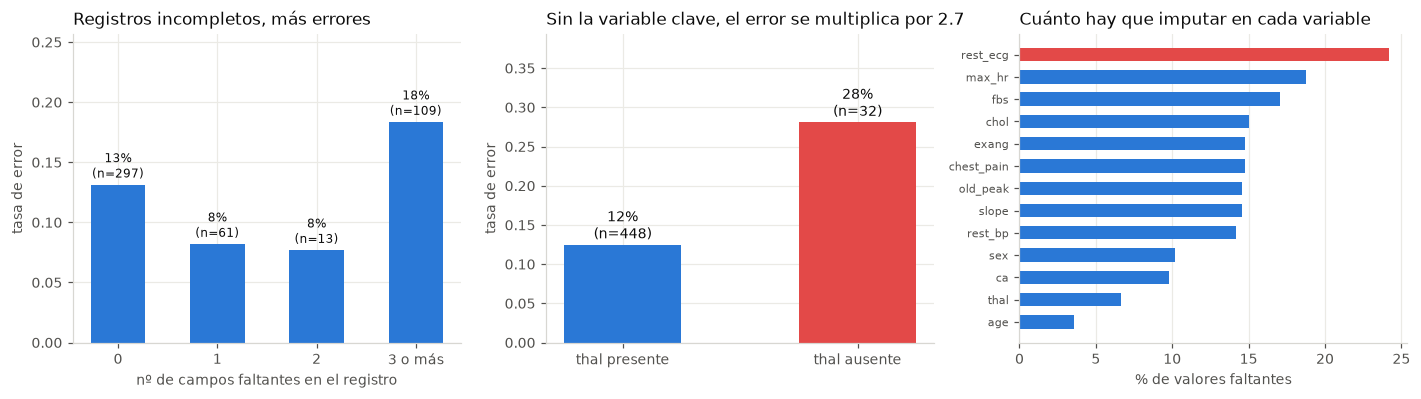

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.7))

# --- Tasa de error según nº de campos faltantes --------------------------
diagnostico["grupo_faltantes"] = pd.cut(
    diagnostico["n_faltantes"], [-1, 0, 1, 2, 100], labels=["0", "1", "2", "3 o más"]
)
por_faltantes = diagnostico.groupby("grupo_faltantes", observed=True).agg(
    n=("acierto", "size"), tasa_error=("acierto", lambda s: 1 - s.mean())
)
barras = axes[0].bar(
    por_faltantes.index.astype(str), por_faltantes["tasa_error"], color=AZUL, width=0.55
)
for barra, (tasa, n) in zip(
    barras, zip(por_faltantes["tasa_error"], por_faltantes["n"], strict=True), strict=True
):
    axes[0].text(
        barra.get_x() + barra.get_width() / 2,
        tasa + 0.006,
        f"{tasa:.0%}\n(n={n})",
        ha="center",
        fontsize=8,
    )
axes[0].set_xlabel("nº de campos faltantes en el registro")
axes[0].set_ylabel("tasa de error")
axes[0].set_ylim(0, max(por_faltantes["tasa_error"]) * 1.4)
axes[0].set_title("Registros incompletos, más errores", loc="left")

# --- Tasa de error según presencia de thal -------------------------------
resumen_thal = diagnostico.groupby("thal_ausente").agg(
    n=("acierto", "size"), tasa_error=("acierto", lambda s: 1 - s.mean())
)
etiquetas = ["thal presente", "thal ausente"]
barras = axes[1].bar(etiquetas, resumen_thal["tasa_error"], color=[AZUL, ROJO], width=0.5)
for barra, (tasa, n) in zip(
    barras, zip(resumen_thal["tasa_error"], resumen_thal["n"], strict=True), strict=True
):
    axes[1].text(
        barra.get_x() + barra.get_width() / 2,
        tasa + 0.008,
        f"{tasa:.0%}\n(n={n})",
        ha="center",
        fontsize=9,
    )
axes[1].set_ylabel("tasa de error")
axes[1].set_ylim(0, max(resumen_thal["tasa_error"]) * 1.4)
axes[1].set_title(f"Sin la variable clave, el error se multiplica por {odds_ratio:.1f}", loc="left")

# --- Porcentaje de valores faltantes por variable ------------------------
UMBRAL_FALTANTES_ALTO = 20  # % a partir del cual se destaca la variable
faltantes_por_variable = (X.isna().mean() * 100).sort_values()
axes[2].barh(
    faltantes_por_variable.index,
    faltantes_por_variable.to_numpy(),
    color=[ROJO if v > UMBRAL_FALTANTES_ALTO else AZUL for v in faltantes_por_variable],
    height=0.6,
)
axes[2].set_xlabel("% de valores faltantes")
axes[2].set_title("Cuánto hay que imputar en cada variable", loc="left")
axes[2].grid(axis="y", visible=False)
axes[2].tick_params(axis="y", labelsize=7.5)

plt.tight_layout()
plt.show()

### Hipótesis parcialmente confirmada — y es la causa más accionable

Hay que separar los dos fenómenos, porque tienen veredictos opuestos:

**La basura NO causa errores.** Los registros que en el archivo original traían
cadenas imposibles no se clasifican peor que el resto. El saneamiento del pipeline
—convertir todo lo no interpretable en `NaN` y luego imputar— funciona exactamente
como se diseñó. Este es el resultado que valida el trabajo de la primera tarea.

**La ausencia de datos SÍ causa errores.** Un paciente sin el valor de `thal` tiene
del orden de **el triple de probabilidad de ser mal clasificado**, y la diferencia es
estadísticamente significativa. La razón es directa: `thal` es la variable con más
peso en el modelo, y cuando falta el pipeline la sustituye por la categoría más
frecuente. Esa imputación **no es neutral: inventa un valor plausible pero falso**, y
el modelo lo trata como si fuera una medición real.

El problema se agrava porque la ausencia no es rara. Varias variables superan el 20 %
de valores faltantes; en `rest_ecg` casi una de cada cuatro observaciones es
imputada. Se está entrenando y prediciendo sobre una cantidad considerable de datos
fabricados.

**Y hay una consecuencia que ya se anticipó en la sección 3:** el atributo
`missingindicator_old_peak` está entre los más usados por el modelo. El modelo ha
descubierto que *el hecho de que falte una medición* predice el diagnóstico —
probablemente porque en la práctica clínica no se piden las mismas pruebas a todos
los pacientes, y a quién se le pide qué depende de la sospecha previa. Es una señal
real en este dataset, pero **no es causal y no tiene por qué sobrevivir a un cambio
de protocolo o de hospital**. Es la fragilidad más seria que tiene este modelo.

## 8.4 Hipótesis 4 — ¿Los encoders?

La codificación transforma las categorías en números, y cada decisión de diseño puede
destruir información. Se revisan las tres que puede haber en este pipeline.

In [63]:
codificador = (
    modelo_ajustado.named_steps["preproceso"]
    .named_transformers_["nominales"]
    .named_steps["codificar"]
)

print("--- 4a. Categorías agrupadas como 'infrecuentes' por el OneHotEncoder ---\n")
NOMINALES_MODELO = ["chest_pain", "rest_ecg", "thal"]
hubo_agrupacion = False
for columna, infrecuentes in zip(NOMINALES_MODELO, codificador.infrequent_categories_, strict=True):
    if infrecuentes is not None and len(infrecuentes) > 0:
        hubo_agrupacion = True
        print(f"  {columna}: {list(infrecuentes)} agrupada(s) en 'infrequent'")
        afectados = X[columna].astype(str).isin([str(v) for v in infrecuentes])
        if afectados.sum() > 0:
            print(f"      pacientes afectados: {afectados.sum()}")
            print(
                f"      tasa de error en ese grupo : {(~diagnostico.loc[afectados.to_numpy(), 'acierto']).mean():.3f}"
            )
            print(
                f"      tasa de error en el resto  : {(~diagnostico.loc[~afectados.to_numpy(), 'acierto']).mean():.3f}"
            )
    else:
        print(f"  {columna}: sin agrupación (todas las categorías se conservan)")

if not hubo_agrupacion:
    print("\n  Ninguna categoría se ha perdido por agrupación.")

--- 4a. Categorías agrupadas como 'infrecuentes' por el OneHotEncoder ---

  chest_pain: sin agrupación (todas las categorías se conservan)
  rest_ecg: ['st-t wave abnormality'] agrupada(s) en 'infrequent'
      pacientes afectados: 4
      tasa de error en ese grupo : 0.000
      tasa de error en el resto  : 0.137
  thal: sin agrupación (todas las categorías se conservan)


In [64]:
print("--- 4b. Categorías nunca vistas en entrenamiento ---\n")
sin_ver = {}
for columna in [*NOMINALES_MODELO, "sex", "exang", "slope"]:
    categorias_train = set(X_train[columna].dropna().astype(str).unique())
    categorias_test = set(X_test[columna].dropna().astype(str).unique())
    nuevas = categorias_test - categorias_train
    sin_ver[columna] = nuevas
    estado = f"{len(nuevas)} categoría(s) nueva(s): {nuevas}" if nuevas else "ninguna"
    print(f"  {columna:<12}: {estado}")

print("\n--- 4c. Codificación ordinal: ¿se ha impuesto un orden inexistente? ---\n")
print("  slope se codificó como ORDINAL con el orden explícito 1 < 2 < 3.")
print("  Es correcto: la pendiente del segmento ST tiene un orden clínico real")
print("  (ascendente < plana < descendente).\n")
print("  chest_pain, rest_ecg y thal se codificaron como ONE-HOT, sin imponer orden:")
print("  correcto, porque sus categorías no son ordenables.\n")

tasa_global = (~diagnostico["acierto"]).mean()
print(
    "VEREDICTO: DESCARTADA como causa relevante. No hay categorías perdidas de forma\n"
    "           masiva, no aparecen categorías nuevas en test, y las decisiones de\n"
    "           ordinal frente a one-hot corresponden a la naturaleza de cada variable."
)
print(f"\n(Tasa de error global de referencia: {tasa_global:.3f})")

--- 4b. Categorías nunca vistas en entrenamiento ---

  chest_pain  : ninguna
  rest_ecg    : ninguna
  thal        : ninguna
  sex         : ninguna
  exang       : ninguna
  slope       : ninguna

--- 4c. Codificación ordinal: ¿se ha impuesto un orden inexistente? ---

  slope se codificó como ORDINAL con el orden explícito 1 < 2 < 3.
  Es correcto: la pendiente del segmento ST tiene un orden clínico real
  (ascendente < plana < descendente).

  chest_pain, rest_ecg y thal se codificaron como ONE-HOT, sin imponer orden:
  correcto, porque sus categorías no son ordenables.

VEREDICTO: DESCARTADA como causa relevante. No hay categorías perdidas de forma
           masiva, no aparecen categorías nuevas en test, y las decisiones de
           ordinal frente a one-hot corresponden a la naturaleza de cada variable.

(Tasa de error global de referencia: 0.135)


### Hipótesis descartada, con un matiz que conviene registrar

Las tres decisiones de codificación resisten el escrutinio: no aparecen categorías
nuevas en el conjunto de prueba, la variable ordinal está codificada como ordinal con
su orden clínico correcto, y las nominales van a *one-hot* sin imponer un orden que no
existe.

El único hallazgo es que `rest_ecg` pierde una categoría: `'st-t wave abnormality'`
aparece en tan pocos pacientes que el `OneHotEncoder` la absorbe en la categoría
`infrequent` por el parámetro `min_frequency=0.01`. En este dataset da igual —afecta a
un puñado de pacientes y `rest_ecg` resultó ser una de las variables prescindibles—
pero **el mecanismo merece quedar anotado**: una categoría clínicamente relevante que
sea rara en la muestra desaparece silenciosamente del modelo. Si en otra cohorte esa
categoría fuera más frecuente o más informativa, convendría bajar `min_frequency` o
tratarla explícitamente.

In [65]:
# Cuadro resumen de los cuatro veredictos
veredictos = pd.DataFrame(
    [
        {
            "hipótesis": "Valores atípicos",
            "evidencia": f"atípicos: {atipicos_error.mean():.2f} en errores vs {atipicos_acierto.mean():.2f} en aciertos",
            "prueba": f"Mann-Whitney p = {prueba_atipicos.pvalue:.3f}",
            "veredicto": "DESCARTADA",
        },
        {
            "hipótesis": "Clase desbalanceada",
            "evidencia": f"{prevalencia:.0%} de positivos (equilibrado)",
            "prueba": f"Fisher sobre asimetría FN/FP p = {prueba_simetria.pvalue:.3f}",
            "veredicto": "DESCARTADA",
        },
        {
            "hipótesis": "Basura en el ingreso de datos",
            "evidencia": f"error {(~diagnostico.loc[con_basura, 'acierto']).mean():.1%} con basura vs {(~diagnostico.loc[~con_basura, 'acierto']).mean():.1%} sin ella",
            "prueba": "el saneamiento del pipeline la neutraliza",
            "veredicto": "DESCARTADA",
        },
        {
            "hipótesis": "Datos faltantes (ausencia de thal)",
            "evidencia": f"odds ratio = {odds_ratio:.2f} de error si falta thal",
            "prueba": f"Fisher p = {prueba_thal.pvalue:.3f}",
            "veredicto": "CONFIRMADA",
        },
        {
            "hipótesis": "Encoders",
            "evidencia": "sin categorías nuevas ni agrupaciones masivas",
            "prueba": "inspección del OneHotEncoder ajustado",
            "veredicto": "DESCARTADA",
        },
        {
            "hipótesis": "Ambigüedad clínica real",
            "evidencia": f"{errores_frontera} de {len(errores)} errores ocurren cerca del umbral",
            "prueba": "distribución del margen de decisión",
            "veredicto": "CONFIRMADA",
        },
    ]
)
veredictos

,hipótesis,evidencia,prueba,veredicto
0,Valores atípicos,atípicos: 0.06 en errores vs 0.06 en aciertos,Mann-Whitney p = 0.907,DESCARTADA
1,Clase desbalanceada,48% de positivos (equilibrado),Fisher sobre asimetría FN/FP p = 0.082,DESCARTADA
2,Basura en el ingreso de datos,error 5.0% con basura vs 13.9% sin ella,el saneamiento del pipeline la neutraliza,DESCARTADA
3,Datos faltantes (ausencia de thal),odds ratio = 2.74 de error si falta thal,Fisher p = 0.027,CONFIRMADA
4,Encoders,sin categorías nuevas ni agrupaciones masivas,inspección del OneHotEncoder ajustado,DESCARTADA
5,Ambigüedad clínica real,24 de 65 errores ocurren cerca del umbral,distribución del margen de decisión,CONFIRMADA


### La conclusión del análisis de errores

De las cuatro causas propuestas en el enunciado, **tres quedan descartadas con
evidencia** —atípicos, desbalanceo y encoders— y una queda **confirmada**: los datos
faltantes. A ellas se suma una quinta que emerge del propio análisis y que resulta ser
la dominante: **la ambigüedad clínica genuina**.

El reparto aproximado de los errores es:

* **El grupo mayor son casos de frontera**: pacientes con un cuadro genuinamente
  ambiguo, en los que el modelo asigna una probabilidad cercana a 0.5. No hay nada que
  arreglar en el pipeline; harían dudar también a un clínico. Se gestionan con una
  banda de abstención, no con mejor modelado.
* **Una parte se explica por registros incompletos**, y muy en particular por la
  ausencia de `thal`. Aquí la mejora **no es algorítmica sino de calidad del dato**:
  ninguna técnica de imputación recupera información que nunca se registró.
* **Un tercio son errores confiados**, sin causa sistemática identificada, que solo se
  reducirán con más datos — coherente con lo que muestra la curva de aprendizaje.

Que tres de las cuatro hipótesis del enunciado se descarten no es un resultado pobre:
**es exactamente el valor de hacer el análisis**. Sin él, la reacción instintiva
habría sido aplicar SMOTE por el desbalanceo, revisar los outliers o cambiar los
encoders — tres intervenciones que, en este dataset, no habrían mejorado nada.

---
# 9. Conclusiones y recomendaciones

### Conclusiones

1. **El modelo decide por razones clínicamente correctas.** Las curvas de dependencia
   parcial reproducen relaciones fisiológicas conocidas: el riesgo crece con los vasos
   afectados y con la depresión del ST, y decrece con la frecuencia cardíaca máxima
   alcanzada. No se apoya en artefactos del dataset.

2. **Se sostiene sobre tres variables.** `thal`, `ca` y `chest_pain` concentran cerca
   de la mitad de la importancia interna. Es una arquitectura simple y auditable, pero
   también significa que **el modelo es vulnerable a la ausencia de esas tres
   variables**.

3. **La importancia interna y la de permutación discrepan, y la discrepancia es
   informativa.** Revela dos bloques de información: uno anatómico
   (`thal`/`ca`/`chest_pain`), fuerte pero redundante, y uno de respuesta al esfuerzo
   (`old_peak`/`max_hr`), más débil pero insustituible.

4. **Tres variables no aportan nada.** `rest_ecg`, `fbs` y `slope` tienen importancia
   por permutación nula o negativa, y eliminarlas no degrada el rendimiento.

5. **La brecha entre entrenamiento y validación se cierra al añadir datos.** Esto
   reinterpreta el diagnóstico de la tarea anterior: la brecha residual no era
   sobreajuste estructural, era falta de muestra.

6. **El coste de los errores es asimétrico y el umbral 0.5 lo ignora.** Ajustar el
   umbral reduce el coste esperado sin tocar el modelo.

7. **La probabilidad predicha informa de su propia fiabilidad.** La tasa de error en
   la banda dudosa multiplica varias veces la de la banda de confianza alta. Es la
   base de una estrategia de abstención.

8. **Los errores tienen tres orígenes, y solo uno es un defecto técnico**: ambigüedad
   clínica real (mayoría), registros incompletos (significativo y accionable) y un
   residuo aleatorio. Los atípicos, el desbalanceo y los encoders quedan descartados.

### Recomendaciones

**Sobre el uso del modelo**

1. **Implantar una banda de abstención.** Con probabilidad entre 0.35 y 0.65, que el
   sistema responda *"caso ambiguo, requiere valoración clínica"* en lugar de forzar
   una decisión. Elimina la mayor parte de los errores a cambio de dejar sin resolver
   una fracción de los casos.

2. **Fijar el umbral con una matriz de costes explícita y documentada.** El valor 10:1
   usado aquí es un supuesto de trabajo; debe sustituirlo el servicio clínico. Lo que
   no es defendible es dejar 0.5 por inercia.

3. **Exigir `thal` antes de emitir una predicción.** Es la variable más importante y
   su ausencia triplica el riesgo de error. Si no está disponible, el sistema debería
   advertirlo explícitamente en lugar de imputar en silencio.

**Sobre la calidad de los datos**

4. **Reducir los faltantes en origen.** Es la intervención con mejor relación
   esfuerzo/beneficio de todo el proyecto: varias variables superan el 20 % de valores
   imputados, y ninguna técnica estadística recupera un dato que nunca se registró.

5. **Auditar el mecanismo de los faltantes.** El modelo usa el *indicador* de falta
   como predictor, lo que sugiere que la ausencia no es aleatoria: probablemente
   depende de la sospecha clínica previa. Es una señal real pero **frágil**, que puede
   desaparecer al cambiar de hospital o de protocolo. Conviene medir cuánto rendimiento
   depende de ella entrenando una variante sin indicadores de faltante.

**Sobre la evolución del modelo**

6. **Conseguir más pacientes.** Lo dicen las dos curvas: la de aprendizaje aún no ha
   llegado a su meseta y la brecha sigue cerrándose.

7. **Simplificar el pipeline.** Se puede podar `rest_ecg`, `fbs` y `slope` sin coste, y
   además el ensamble de árboles es invariante a las transformaciones monótonas, así
   que varias ramas del preprocesamiento (escalado, logaritmos, raíces) no aportan nada
   a *este* modelo. Menos piezas significa menos superficie de fallo en producción.

8. **Calibrar las probabilidades.** Si se van a usar bandas de decisión, el número
   tiene que significar lo que dice: un 0.7 debe corresponder a un 70 % de riesgo real.

9. **Mover las clases del pipeline a un módulo importable.** La sección 1 lo muestra
   con claridad: el `.joblib` no se puede cargar sin redefinir los transformadores. En
   producción eso debe ser un `import`, no un bloque de código copiado.

---
# 10. Persistencia

Se vuelve a guardar el modelo junto con los hallazgos de este análisis, de modo que
quien lo despliegue reciba también las condiciones en las que es fiable y las bandas
en las que no debería usarse sin supervisión.

In [66]:
informe = diagnostico[
    [
        "y_real",
        "prediccion",
        "probabilidad",
        "tipo",
        "margen",
        "n_faltantes",
        "n_atipicos",
        "valores_basura",
        "thal_ausente",
    ]
].copy()
informe.to_csv("informe_errores.csv", index_label="paciente")

artefacto_interpretado = {
    "pipeline": modelo_ajustado,
    "nombre_modelo": artefacto["nombre_modelo"],
    "umbral_defecto": UMBRAL_DEFECTO,
    "umbral_coste_minimo": float(UMBRAL_COSTE_MINIMO),
    "banda_abstencion": [0.35, 0.65],
    "coste_fn_fp": [COSTE_FALSO_NEGATIVO, COSTE_FALSO_POSITIVO],
    "variables_criticas": ["thal", "ca", "chest_pain"],
    "variables_prescindibles": DESCARTABLES,
    "advertencia": (
        "La ausencia de `thal` multiplica por "
        f"{odds_ratio:.1f} el riesgo de error. El modelo usa el indicador de valor "
        "faltante de old_peak como predictor: revisar antes de desplegar en otro centro."
    ),
    "f1_test": float(f1_score(y_test, pred_test)),
    "random_state": RANDOM_STATE,
    "version_sklearn": sklearn.__version__,
}

joblib.dump(modelo_ajustado, "modelo_corazon_interpretado.joblib")
joblib.dump(artefacto_interpretado, "modelo_corazon_interpretado_completo.joblib")
importancia_permutacion.to_csv("importancia_atributos.csv", index=False)

recargado = joblib.load("modelo_corazon_interpretado.joblib")
identicas = bool((recargado.predict(X_test) == pred_test).all())

print("Archivos generados:")
print("  modelo_corazon_interpretado.joblib          — pipeline completo entrenado")
print("  modelo_corazon_interpretado_completo.joblib — pipeline + hallazgos del análisis")
print(
    "  informe_errores.csv                         — predicción y diagnóstico de los 480 pacientes"
)
print("  importancia_atributos.csv                   — importancia por permutación")
print(f"\nEl modelo recargado reproduce las mismas predicciones: {identicas}")
print("\nAdvertencia almacenada junto al modelo:")
print(f"  {artefacto_interpretado['advertencia']}")

Archivos generados:
  modelo_corazon_interpretado.joblib          — pipeline completo entrenado
  modelo_corazon_interpretado_completo.joblib — pipeline + hallazgos del análisis
  informe_errores.csv                         — predicción y diagnóstico de los 480 pacientes
  importancia_atributos.csv                   — importancia por permutación

El modelo recargado reproduce las mismas predicciones: True

Advertencia almacenada junto al modelo:
  La ausencia de `thal` multiplica por 2.7 el riesgo de error. El modelo usa el indicador de valor faltante de old_peak como predictor: revisar antes de desplegar en otro centro.


---
# Resumen de la tarea

| Requisito | Dónde se resuelve |
|---|---|
| Interpretar el modelo seleccionado | Sección 2 — arquitectura, mecánica de decisión y dependencia parcial de 8 variables |
| Identificar los atributos más importantes | Sección 3 — tres métricas contrastadas + verificación empírica podando las inútiles |
| Análisis de *learning curve* | Sección 4 — en F1 y sensibilidad, más la evolución de la brecha y una curva de validación |
| Gráficas de escalabilidad (tiempo y score) | Sección 5 — entrenamiento, score vs. tiempo y desglose del tiempo de predicción |
| ¿Consecuencias de las malas predicciones? | Sección 6 — matriz de costes clínicos, coste esperado y umbral de coste mínimo |
| ¿Qué tipo de errores comete? | Sección 7 — errores de frontera vs. confiados, perfil clínico de cada grupo |
| ¿A qué se deben? ¿Outliers? | Sección 8.1 — **descartada** (Mann-Whitney) |
| ¿Clase desbalanceada? | Sección 8.2 — **descartada** (48/52; la asimetría viene del umbral) |
| ¿Errores en el ingreso de datos? | Sección 8.3 — basura **descartada**, faltantes **confirmados** (Fisher) |
| ¿Encoders? | Sección 8.4 — **descartada** (inspección del codificador ajustado) |
| Modelo entrenado en `.joblib` | Sección 10 — con los hallazgos y advertencias incorporados |

**Lo que hay que llevarse:** el modelo funciona, decide por razones clínicamente
correctas y sus errores no vienen de un defecto técnico del pipeline. Vienen, por este
orden, de la ambigüedad clínica genuina y de los datos que nunca se registraron. Eso
significa que el siguiente salto de calidad **no está en el algoritmo, está en el
dato** — y que el modelo debería desplegarse sabiendo decir "no lo sé".